# Goh Wen San CA2 Part A
Name: Goh Wen San

ID: p2518367

Class: DAAA/FFT/1B/07

# BACKGROUND:
collected the information of 200 customers including their Gender, Age, Income
and How much they spend. We want to group the customers into clusters so that we
can cater the needs for different customers.

# OBJECTIVE: Use unsupervised learning to
1) Perform customer segmentation in Python 
2) Describe characteristics of each cluster
3) Identify which cluster needs the most attention and why

## Machine Learning Workflow Summary 

This customer segmentation study follows a structured unsupervised machine learning workflow:

1. **Problem definition:** Group customers into meaningful clusters to support targeted strategies.
2. **Data understanding:** Inspect dataset structure, data types, missing values, and basic distributions.
3. **Exploratory Data Analysis (EDA):** Visualize feature distributions and relationships to anticipate clustering behaviour.
4. **Preprocessing:** Remove non-informative identifiers, encode categorical variables (Gender), and scale features for distance-based models.
5. **Feature engineering:** Create additional behaviour-based features (e.g., spending relative to income/age) to improve segmentation.
6. **Model experimentation:** Test multiple clustering algorithms (KMeans, Hierarchical, GMM) and different values of k.
7. **Model selection:** Determine the best k using objective metrics (silhouette, inertia/elbow, BIC for GMM) and interpretability.
8. **Result analysis:** Profile each cluster and identify which group needs more attention.


## Importing all the neccessary libraries

In [3]:
        import os
os.environ["OMP_NUM_THREADS"] = "1" 

# Basic Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Sklearn Libraries
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

## Loading of Dataset

In [4]:
df = pd.read_csv('C:/Users/wensa/1.sp AIML/CA2/DATA/CA2-Customer-Data.csv')
df.head()

,CustomerID,Gender,Age,Income (k$),How Much They Spend
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
  dtype={
        "CustomerID": "int64",          # Unique ID of the customer 
        "Gender": "string",             # Gender of the customer 
        "Age": "int64",                 # Age of the customer 
        "Income (k$)": "int64",         # Annual income in thousands of dollars 
        "How Much They Spend": "int64"  # Dollars spent by the customer 
    }

# Check the data types
allTypes = df.dtypes
print(allTypes)

CustomerID              int64
Gender                 object
Age                     int64
Income (k$)             int64
How Much They Spend     int64
dtype: object


# Step 1: Exploratory Data Analysis (EDA)

This first step builds a strong foundation for understanding the customer dataset and how each feature may influence the grouping of customers into clusters. It involves analysing this dataset since clustering is distance-based, understanding the variables is important before preprocessing and modelling.Therefore, i first need to gain a brief understanding of the dataset features used for segmentation: Gender, Age, Income (k$), and How Much They Spend, along with the CustomerID column.

1. CustomerID (Numerical)
- This is a unique ID assigned to each customer it is mainly used for tracking and indexing rows and is not a meaningful feature for clustering, because it does not describe customer behaviour or characteristics.

2. Gender (Categorical)
- This represents the customer’s gender  where it may influence purchasing patterns and segmentation since clustering requires numeric input, this feature will later be encoded during preprocessing.

3. Age (Numerical)
- This indicates the customer’s and may relate to lifestyle and spending behaviour e.g., younger customers might spend differently from older customers.Hence during EDA, i will check its distribution eg. range, skewness and outliers.

4. Income (k$) (Numerical)
- This represents the customer’s annual income measured in thousands of dollars it is often a key factor in customer segmentation because it affects purchasing power i will examine how income varies across customers and whether it shows relationships with spending.

5. How Much They Spend (Numerical)
- This indicates the customer’s spending amount or spending score depending on dataset definition.This is a crucial variable because segmentation often aims to differentiate customers based on their spending behaviour.


#### 1) first i will remove the "CustomerID", known as the meta data or data that will not play a part in clustering the customers to cater to their needs.

In [6]:
# dropping of row
df.drop(columns='CustomerID', inplace=True)
print(df.columns)

Index(['Gender', 'Age', 'Income (k$)', 'How Much They Spend'], dtype='object')


#### 2) Next i will create another copy of df to prevent accidentally making changes to out main dataset

In [7]:
df_copy = df.copy()

In [8]:
# Get description 
df_copy.describe()

,Age,Income (k$),How Much They Spend
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [9]:
#Getting the rows and columns 
df_copy.shape

(200, 4)

In [10]:
#Get data types and non-null counts for each column
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Gender               200 non-null    object
 1   Age                  200 non-null    int64 
 2   Income (k$)          200 non-null    int64 
 3   How Much They Spend  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [11]:
#Check for duplicates
df_copy.duplicated().sum()

np.int64(0)

From the above i can tell that there isnt any duplicates hence there is no need to remove any data 

In [12]:
# checking the types of gender to deal with
df_copy['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [13]:
# Count of unique values in each column
print("Unique values in each column:")
print(df_copy.nunique())

Unique values in each column:
Gender                  2
Age                    51
Income (k$)            64
How Much They Spend    84
dtype: int64


### check for missing data : 

In [14]:
# checking for empty values
df_copy.isnull().sum()

Gender                 0
Age                    0
Income (k$)            0
How Much They Spend    0
dtype: int64

In [15]:
df_copy.isna().sum()

Gender                 0
Age                    0
Income (k$)            0
How Much They Spend    0
dtype: int64

### Since there is no missing data, i don’t need to impute any values or drop rows the clustering results are also more reliable, because missing-value handling can sometimes introduce biasness. 

In [16]:
# Count of unique values in each column
print("Unique values in each column:")
print(df_copy.nunique())

Unique values in each column:
Gender                  2
Age                    51
Income (k$)            64
How Much They Spend    84
dtype: int64


The dataset shows sufficient variability across Age, Income and Spending, which supports meaningful clustering. Gender has 2 categories and will be encoded during preprocessing

### Now i will use graphs to better visualise the data to identify its distribution, central tendency, spread, and potential issues like skewness or outliers.

##### For each numerical feature (Age, Income, Spending)
- Histogram + KDE
Best for: distribution shape + skewness

- Boxplot
Best for: median (central tendency) + spread (IQR) + outliers

##### For the categorical feature (Gender)
Countplot (bar chart)
Best for: category balance + proportions

## Numerical features : 

# Age

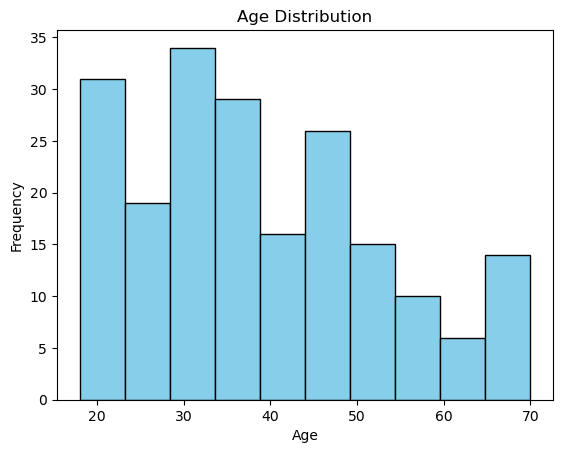

In [17]:
# Histogram for Age
plt.hist(df_copy['Age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

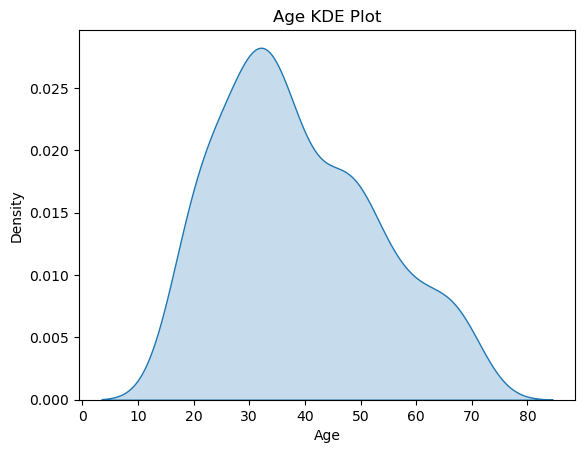

In [18]:
# KDE for Age
plt.figure()
sns.kdeplot(data=df_copy, x="Age", fill=True)
plt.title("Age KDE Plot")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

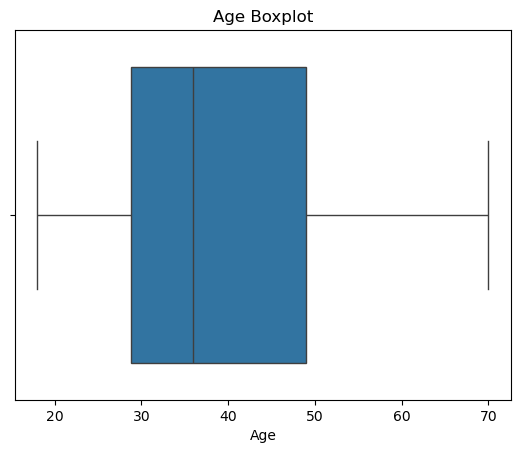

In [19]:
# Boxplot for Age
plt.figure()
sns.boxplot(x=df_copy["Age"])
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.show()

From the graphs above i can tell that The Age distribution is unimodal(  a distribution, function, or dataset that has a single peak or most frequent value ) , with the highest concentration of customers around the late 20s to late 30s and peak roughly around 30 to 35.

1. The KDE curve shows a slight right-skew, meaning there are fewer older customers, but the ages extend gradually into higher values.

2. From the histogram, most customers fall roughly between 20 and 50, with smaller counts above 50.

3. The boxplot suggests a median age around the mid to late 30s, and a moderate spread .

There are no obvious extreme outliers shown in the boxplot so Age is unlikely to cause major issues for clustering, but it should still be scaled together with Income and Spending.

**Implication for clustering:** Age alone may not create clean groups, but it can help separate spending behaviour when combined with income and spending.

# Income

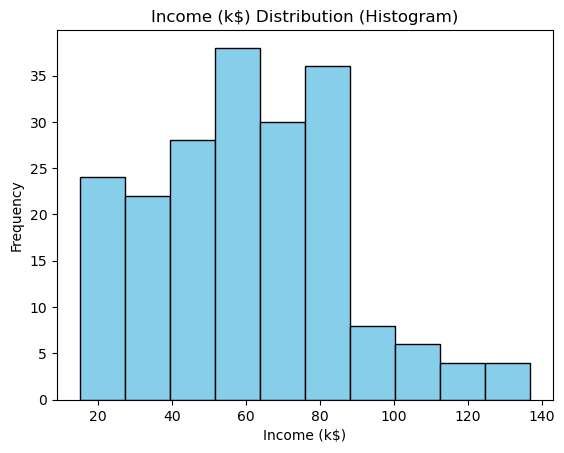

In [20]:
# Histogram for Income
plt.figure()
plt.hist(df_copy["Income (k$)"], bins=10, color="skyblue", edgecolor="black")
plt.title("Income (k$) Distribution (Histogram)")
plt.xlabel("Income (k$)")
plt.ylabel("Frequency")
plt.show()

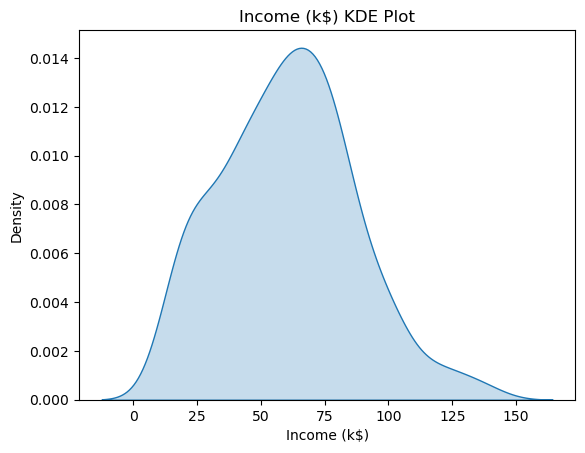

In [21]:
# KDE for Income
plt.figure()
sns.kdeplot(data=df_copy, x="Income (k$)", fill=True)
plt.title("Income (k$) KDE Plot")
plt.xlabel("Income (k$)")
plt.ylabel("Density")
plt.show()

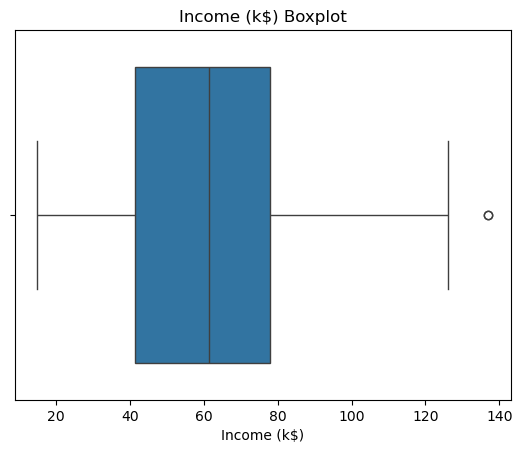

In [22]:
# Boxplot for Income
plt.figure()
sns.boxplot(x=df_copy["Income (k$)"])
plt.title("Income (k$) Boxplot")
plt.xlabel("Income (k$)")
plt.show()

From the graphs i can tell that from the histogram and KDE that the data shows a unimodal distribution, with the most customers income concentrated around 50k to 80k, peaking roughly near 60k to 70k.The distribution is also slightly right-skewed, meaning there are fewer customers with very high income, but the values extend into the higher range.From the spread, income ranges roughly from around 15k up to 140k, showing good variability for clustering.

The boxplot indicates a median income around the mid 60k range, with a moderate IQR and there appears to be at least one high-income outlier on the upper end which could influence distance-based clustering methods like K-Means.

Therefore, Income should be scaled before clustering, and it may be useful to keep an eye on the impact of high-income outliers when interpreting clusters.

**Implication for clustering:** Income has outliers and a wider range, so it can dominate distance calculations = outlier handling + scaling is necessary.


# Spending

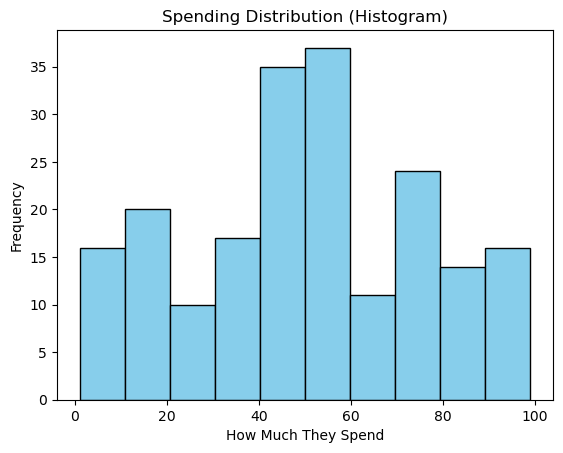

In [23]:
# Histogram for Spending
plt.figure()
plt.hist(df_copy["How Much They Spend"], bins=10, color="skyblue", edgecolor="black")
plt.title("Spending Distribution (Histogram)")
plt.xlabel("How Much They Spend")
plt.ylabel("Frequency")
plt.show()

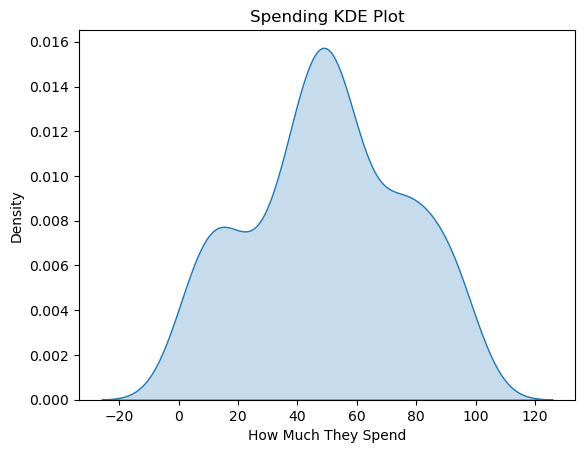

In [24]:
# KDE for Spending
plt.figure()
sns.kdeplot(data=df_copy, x="How Much They Spend", fill=True)
plt.title("Spending KDE Plot")
plt.xlabel("How Much They Spend")
plt.ylabel("Density")
plt.show()

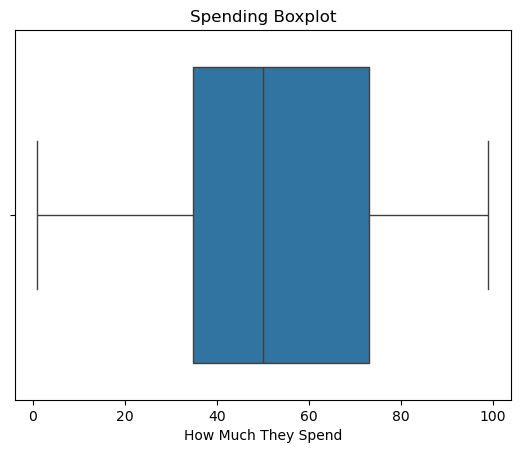

In [25]:
# Boxplot for Spending
plt.figure()
sns.boxplot(x=df_copy["How Much They Spend"])
plt.title("Spending Boxplot")
plt.xlabel("How Much They Spend")
plt.show()

From the graphs i can tell that the spending histogram and KDE show a main peak around 50 to 60, meaning most customers fall in the mid-spending range.

The KDE suggests the distribution is not perfectly normal as it looks slightly  uneven, with smaller bumps at lower spending and higher spending ranges.This implies there may be different spending groups present in the dataset, which supports the idea of customer segmentation.Overall spending values appear to range roughly from 0 to 100, showing good variability for clustering.

The boxplot indicates a median spending around the mid 50s, with a moderate spread and there is no obvious extreme outliers shown hence spending is unlikely to create major outlier issues for clustering.

Since clustering is distance based, Spending should still be scaled together with Age and Income before modelling.

**Implication for clustering:** Spending shows stronger variation than Age, so it is likely a key feature to drive cluster separation (high vs low spenders).

## Categorical features

# Gender

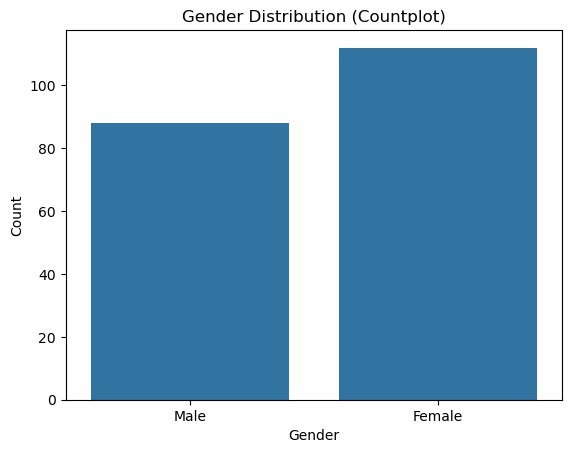

In [26]:
# barchart for gender 
plt.figure()
sns.countplot(data=df_copy, x="Gender")
plt.title("Gender Distribution (Countplot)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

From the barchart i can tell that the dataset contains both Male and Female customers, with Female customers slightly more common than Male customers.Although the difference is not extreme as the dataset is still fairly balanced, which reduces the risk of one gender dominating the clustering results.Since Gender is categorical, it cannot be used directly in distance-based clustering. It will need to be encoded during preprocessing later.

**Implication for clustering:** Gender likely won’t form clusters by itself hence encoding it should be treated as a supporting feature, not the main driver.

## multivariate analysis which is very important for clustering

Multivariate analysis is important for clustering because clustering groups customers based on multiple features together e.g., Age, Income, and Spending, and the real customer segments often appear only when these variables are considered as a combination rather than separately. It helps reveal relationships that create natural separation such as high income with low spend vs high incomehigh spend, prevents misleading results caused by redundant or highly correlated features and makes the final clusters easier to interpret and describe as meaningful customer personas for business decisions.

# graphs used :
1. Regression scatter plot: Income vs Spending
Shows the clearest customer segments

2. Scatterplot: Age vs Spending
Reveals how spending changes across age groups and whether age separates clusters.

3. Scatterplot: Age vs Income
Helps see demographic vs purchasing power patterns that may form clusters.

4. Scatterplots with hue = Gender
Checks if patterns differ by gender and helps interpret clusters later.

5. Pairplot on Age, Income, Spending
Quickly shows all pairwise relationships and possible groupings in one view.

6. Correlation heatmap for numeric only
Detects highly correlated and redundant features that could distort clustering.

7. 3D scatterplot on Age, Income, Spending
Visualizes all three features together, but can be harder to interpret clearly.

8.Boxplot on Age groups
Boxplots show median + spread + outliers by age group, which helps cluster characteristics

### 1) regression scatter plott: Income vs Spending

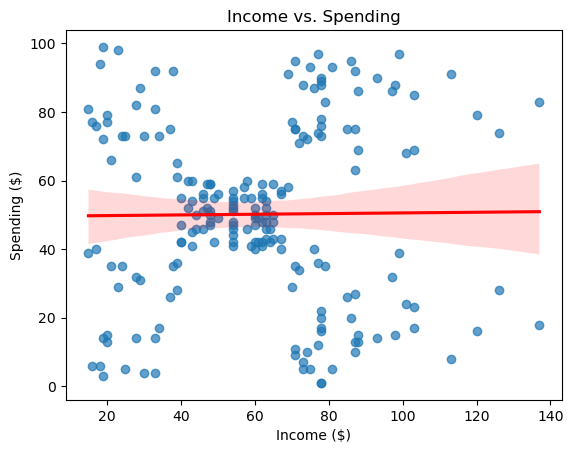

In [27]:
sns.regplot(data=df_copy, x='Income (k$)', y='How Much They Spend', scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
plt.title('Income vs. Spending')
plt.xlabel('Income ($)')
plt.ylabel('Spending ($)')
plt.show()

- From the regression scatter plot i can see that the points are widely scattered, showing that customers with similar income can have very different spending levels.

- The regression line is almost flat with a slight increase suggesting that there is little to no strong linear relationship between income and spending in this dataset.

- There also appears to be distinct spending groups at similar income levels which supports the idea that segmentation is needed rather than using income alone.

- At higher income ranges, spending still varies greatly, indicating that high income does not automatically mean high spending.

Overall, this plot suggests that Income alone is not sufficient to predict Spending, and clustering using multiple features will likely produce more meaningful customer groups.

### 2) Scatterplot: Age vs Spending

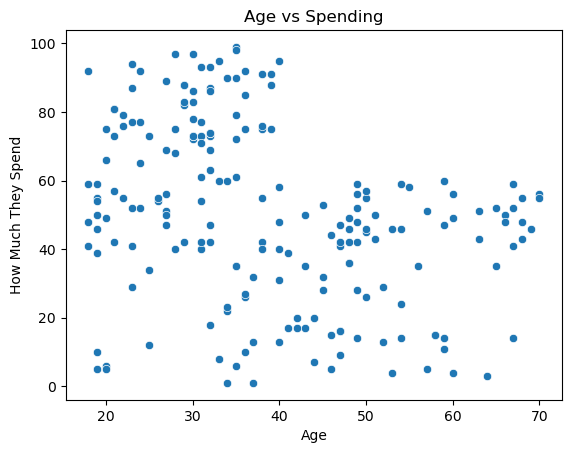

In [28]:
plt.figure()
sns.scatterplot(data=df_copy, x="Age", y="How Much They Spend")
plt.title("Age vs Spending")
plt.xlabel("Age")
plt.ylabel("How Much They Spend")
plt.show()

- From the scatterplot i can see that the points are fairly scattered, showing there is no strong linear relationship between age and spending.

- However, there is a visible pattern where younger customers around 18 to 40 include many high spenders spending arounf 70 to 100 suggesting that higher spending is more common in the younger group.While for older customers around 45 to 70 most spending values appear to cluster around the mid range of 35 to 60 with fewer extremely high spenders.

- There are also low spenders across nearly all age groups, meaning age alone does not fully explain spending behaviour.

Overall, this suggests age may help differentiate certain groups but effective segmentation should still combine Age with Income and Spending together.

### 3) Scatterplot: Age vs Income

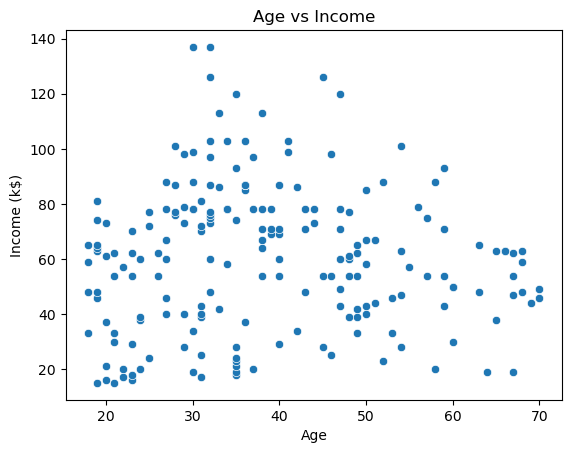

In [29]:
plt.figure()
sns.scatterplot(data=df_copy, x="Age", y="Income (k$)")
plt.title("Age vs Income")
plt.xlabel("Age")
plt.ylabel("Income (k$)")
plt.show()

- From the scatterplot i can tell that the points are widely dispersed, indicating no strong linear relationship between age and income in this dataset.

- Customers across most age ranges especially around 20 to 60 show a broad spread of income values meaning people of similar age can have very different incomes.

- There are some higher-income customers around 100k to 140k mainly appearing in the adult age range of 30 to 50, suggesting peak earning potential may be more common in mid adulthood.

- Older customers around 60 to 70 appear to be more concentrated around mid area incomes roughly around 40k to 70k with fewer extremely high income values.

Overall, since income varies greatly at each age, age alone cannot explain income, and both features should be used together with spending for meaningful customer segmentation.

### 4) Scatterplot with hue : Gender (Income vs Spending)

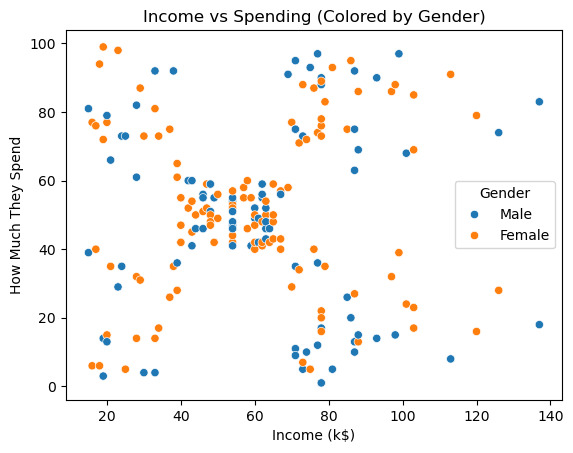

In [30]:
plt.figure()
sns.scatterplot(data=df_copy, x="Income (k$)", y="How Much They Spend", hue="Gender")
plt.title("Income vs Spending (Colored by Gender)")
plt.xlabel("Income (k$)")
plt.ylabel("How Much They Spend")
plt.show()

- From this scatterplot i can tell that both Male and Female customers are spread across the entire income and spending ranges, meaning gender alone does not strongly separate customers into clear groups.

- At similar income levels especially around 40k to 60k both genders show a wide range of spending, including low, medium, and high spenders. This suggests that income does not directly determine spending, regardless of gender.

- The plot shows some clusters but these groups contain a mix of both genders.

Overall, gender appears to be more useful for interpreting clusters rather than being the main driver of clustering by itself, so segmentation should focus primarily on Age, Income, and Spending together.

### 5) Pairplot (Age, Income, Spending) with Gender hue

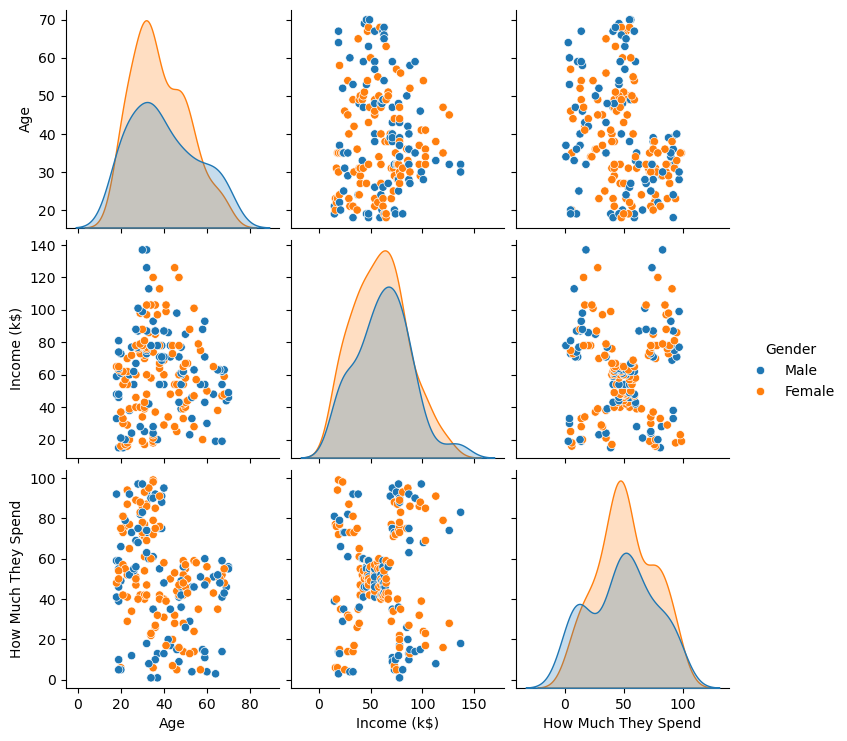

In [31]:
sns.pairplot(df_copy, vars=["Age", "Income (k$)", "How Much They Spend"], hue="Gender")
plt.show()

- The diagonal KDE plots show that Age and Income are roughly unimodal, while Spending appears more uneven suggesting there may be multiple spending groups in the data.

- Across the scatterplots, Gender points overlap heavily, meaning Male and Female customers have very similar distributions for Age, Income, and Spending overall. Gender is unlikely to be the main factor driving clusters.

- The pairwise plots confirm that Income vs Spending does not follow a clear straight line trend where customers with similar incomes can have very different spending levels, supporting the need for clustering.

- The Age vs Spending panels suggest younger customers include more high spenders, while older customers are more concentrated around moderate spending, but there is still wide variability.

Overall, the pairplot suggests that meaningful clusters are more likely to come from combined patterns across Age, Income, and Spending, rather than any single feature or gender alone.

### 6) Correlation Heatmap

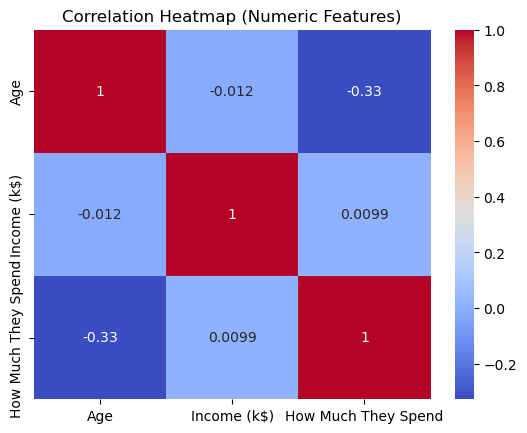

In [32]:
plt.figure()
corr = df_copy[["Age", "Income (k$)", "How Much They Spend"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

- From the heatmap of Age vs Income (k$), the correlation is -0.012, which is almost 0, meaning there is no meaningful linear relationship between age and income in this dataset.

- For Income (k$) vs Spending: The correlation is 0.0099, which is also almost 0 showing that income does not linearly predict spending and customers with similar income can still spend very differently.

- For Age vs Spending: The correlation is -0.33, indicating a moderate negative relationship, meaning that spending tends to decrease as age increases where older customers tend to spend less, although the relationship is not extremely strong.

Overall, the correlations suggest that most features are not highly correlated, which is good because there is low redundancy between features. This supports using Age, Income, and Spending together for clustering, since each feature can contribute unique information to the segmentation.

### 7) 3D Scatterplot on Age, Income, Spending

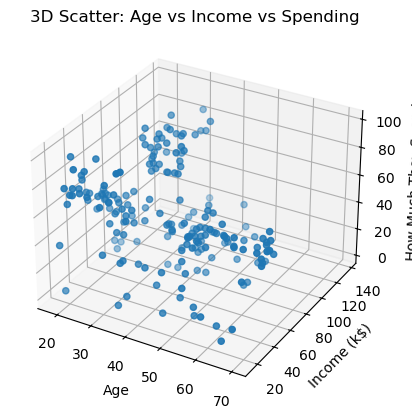

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_copy["Age"], df_copy["Income (k$)"], df_copy["How Much They Spend"])

ax.set_title("3D Scatter: Age vs Income vs Spending")
ax.set_xlabel("Age")
ax.set_ylabel("Income (k$)")
ax.set_zlabel("How Much They Spend")
plt.show()

The 3D plot shows that customers are spread across the 3 variables, indicating that segmentation should consider Age, Income, and Spending together rather than relying on only one feature.There are visible dense clusters of points, suggesting potential customer groups such as:
1. Younger customers with a mix of spending levels 
2. Middle aged customers concentrated more around mid-income and mid-spending
3. Some high income customers with varying spending behaviour

Spending appears to vary greatly even at similar income levels, reinforcing that income alone does not determine spending.As age increases, spending values appear less concentrated at the very high end, supporting the earlier finding that older customers tend to spend moderately compared to younger high spenders.

Overall, the plot supports the presence of multi-dimensional structure in the data, which is suitable for clustering, even though boundaries between groups are not perfectly separated in raw space.

### 8) Boxplot on Age groups

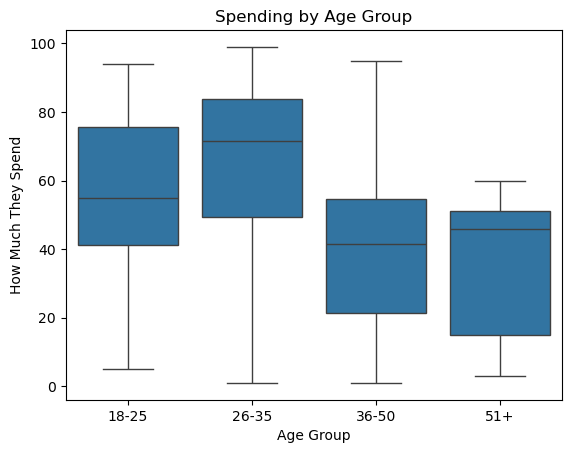

In [34]:
age_bins = [0, 25, 35, 50, 100]
age_labels = ['18-25', '26-35', '36-50', '51+']

df_copy["Age_Group"] = pd.cut(df_copy["Age"], bins=age_bins, labels=age_labels)

plt.figure()
sns.boxplot(data=df_copy, x="Age_Group", y="How Much They Spend")
plt.title("Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("How Much They Spend")
plt.show()

df_copy.drop(columns=["Age_Group"], inplace=True)


The boxplots show clear differences in spending behaviour across age groups, suggesting age is a useful factor for segmentation.

- Ages btw  26 and 35 have the highest median spending, with many customers spending in the higher range, indicating this group tends to be the strongest spending segment overall.

- While ages btw 18 to 25 also show relatively high spending, but with a wider spread, meaning spending behaviour is more varied 

- Ages btw 36 to 50 have a lower median spending compared to younger groups, suggesting spending generally decreases as age increases.

- Ages 51 and above  show the lowest spending levels overall, with the median around the mid-range and fewer high spenders, indicating this group tends to be more moderate

Overall, the trend supports the earlier correlation result that spending tends to decrease with age, and younger groups especially around 26 to 35 appear to be a key group to pay attention to.

# Data processing
Theses are the steps i am planning to take :

1) Handle outliers found in Income (k$)
    What to do: Identify extreme income values and reduce their impact.
    Why: Outliers can pull cluster centers and distort distance calculations, especially for K-Means.

2) Feature Engineering
    What to do: Create features that better represent customer behaviour.
    Why: This captures spending intensity relative to purchasing power, which helps clusters become more meaningful than using raw spending alone.
   
3) Encoding (Categorical -> Numerical)
    What to do: Convert categorical variables into numeric form = Gender: Male = 0, Female = 1
    Age Group: one-hot encode into dummy columns
    Why: Most clustering algorithms require numerical input. Encoding ensures categorical information can be used properly in distance calculations without breaking the model.

4) Scaling
    What to do: Scale all numeric features so they contribute fairly to distance computations .
    Why: Clustering is distance-based; without scaling, features with larger ranges like income may dominate and bias the clustering results.

## 1) Handle outliers in Income (k$)
Capping outliers means limiting extreme values to a reasonable boundary (e.g., using IQR limits) instead of deleting those rows.capping protects the clustering from being dominated by extreme income values while keeping the dataset complete.

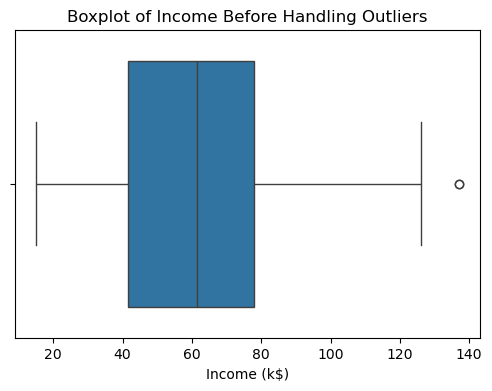

Lower bound: -13.25
Upper bound: 132.75


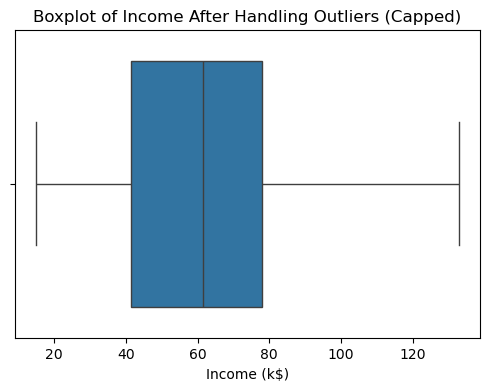

In [35]:
# BEFORE handling outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_copy["Income (k$)"])
plt.title("Boxplot of Income Before Handling Outliers")
plt.xlabel("Income (k$)")
plt.show()

# 2) Define outlier boundaries using IQR
Q1 = df_copy["Income (k$)"].quantile(0.25)
Q3 = df_copy["Income (k$)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Cap outliers, winsorize instead of removing rows
df_copy["Income (k$)"] = df_copy["Income (k$)"].clip(lower_bound, upper_bound)

# AFTER handling outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_copy["Income (k$)"])
plt.title("Boxplot of Income After Handling Outliers (Capped)")
plt.xlabel("Income (k$)")
plt.show()

From the boxplot above i could tell that:
##### Before:
The box contains the middle 50% of income values, roughly around the 40k to 80k range.There is at least one high income outlier the dot on the far right
this means that income value is unusually high compared to most customers and lies outside the typical range.

What the IQR bounds mean:
Lower bound = -13.25
Upper bound = 132.75

This means that:
Any income above 132.75k is considered an outlier by the IQR rule and will be capped.The lower bound is negative, but income can’t realistically be negative that just means there are no low-end outliers in your dataset.

##### After:
After capping, the extreme income value are pulled back to 132.75k, so the outlier dot disappears.The overall distribution remains similar but the dataset is now less influenced by extreme values.

##### Why this matters for clustering
Distance based clustering like K-Means can be heavily affected by extreme values, capping ensures the income feature doesn’t dominate the clustering just because of one unusually high income customer, while still keeping all customers in the dataset.

## 2) Feature Engineering

To improve customer segmentation, I engineered additional features that capture spending behaviour more meaningfully than raw Age, Income, and Spending alone.

1) Spending Ratio (Spending / Income)
Purpose: Identify high spenders VS savers relative to purchasing power.
Why this helps: Two customers can spend the same amount, but the one with lower income is spending more intensely. This feature helps differentiate "budget conscious" customers from luxury spenders, and also separates high-income customers who spend a lot vs those who do not.

2) Age Grouping
Purpose: Capture non-linear spending patterns across life stages.
Why it helps: Spending habits may change by age in a non-linear way, and raw age values may not clearly show these behavioural shifts. Binning the age creates clearer group boundaries and improves interpretation when profiling clusters. 

3) Spending Behavior Score (Spending ÷ (Income + Age))
Purpose: Capture spending tendency beyond income alone.
Why it helps: Some high-income customers spend very little, while some low-income customers spend a lot. This score combines income and age to reflect a customer’s overall “spending intensity,” which can improve cluster separation and reduce the need to manually bin income.

In [36]:
df_fe = df_copy.copy()

eps = 1e-6  

# Spending Ratio (Spending ÷ Income)
df_fe["Spending Ratio"] = df_fe["How Much They Spend"] / (df_fe["Income (k$)"] + eps)

# Spending Behavior Score (Spending ÷ (Income + Age))
df_fe["Spending Behavior Score"] = df_fe["How Much They Spend"] / (df_fe["Income (k$)"] + df_fe["Age"] + eps)

# Age Group (Young, Middle-aged, Senior)
df_fe["Age Group"] = pd.cut(
    df_fe["Age"],
    bins=[0, 25, 45, 100],
    labels=["Young", "Middle-aged", "Senior"]
)


print(df_fe.head())
print("\nColumns now:\n", df_fe.columns)


   Gender  Age  Income (k$)  How Much They Spend  Spending Ratio  \
0    Male   19         15.0                   39        2.600000   
1    Male   21         15.0                   81        5.400000   
2  Female   20         16.0                    6        0.375000   
3  Female   23         16.0                   77        4.812500   
4  Female   31         17.0                   40        2.352941   

   Spending Behavior Score    Age Group  
0                 1.147059        Young  
1                 2.250000        Young  
2                 0.166667        Young  
3                 1.974359        Young  
4                 0.833333  Middle-aged  

Columns now:
 Index(['Gender', 'Age', 'Income (k$)', 'How Much They Spend', 'Spending Ratio',
       'Spending Behavior Score', 'Age Group'],
      dtype='object')


#### Since i am more of a visual learner i added scatter plot and boxplot to better visualise what has changed 

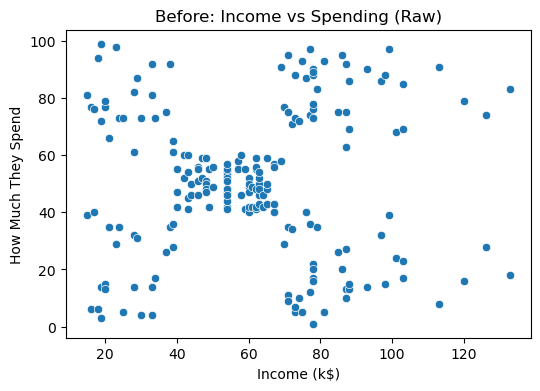

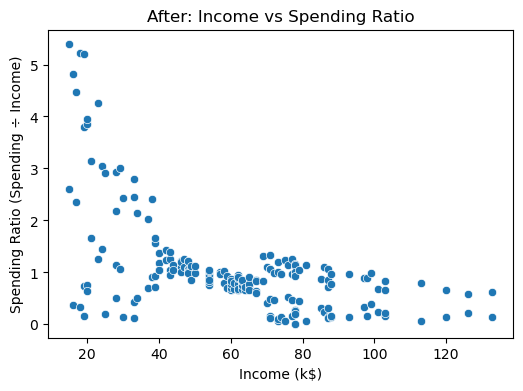

In [37]:
# BEFORE Income vs Spending raw
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_copy, x="Income (k$)", y="How Much They Spend")
plt.title("Before: Income vs Spending (Raw)")
plt.xlabel("Income (k$)")
plt.ylabel("How Much They Spend")
plt.show()

# AFTER  Income vs Spending Ratio
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_fe, x="Income (k$)", y="Spending Ratio")
plt.title("After: Income vs Spending Ratio")
plt.xlabel("Income (k$)")
plt.ylabel("Spending Ratio (Spending ÷ Income)")
plt.show()


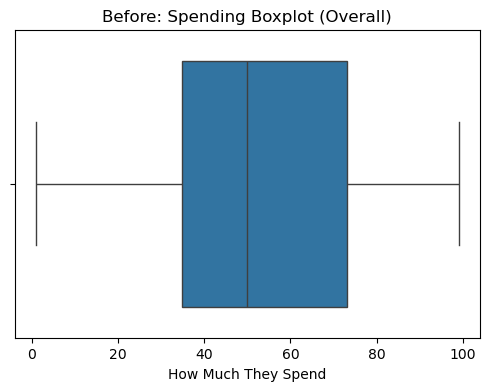

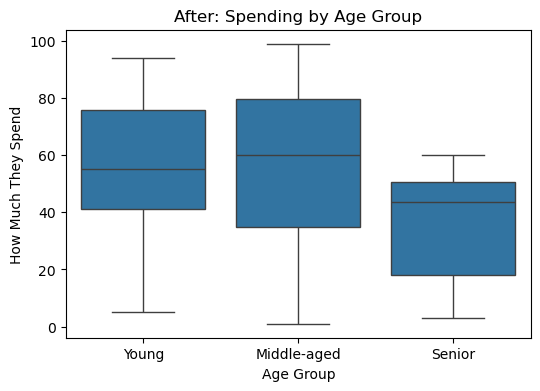

In [38]:
# BEFORE Spending overall (raw)
plt.figure(figsize=(6,4))
sns.boxplot(x=df_copy["How Much They Spend"])
plt.title("Before: Spending Boxplot (Overall)")
plt.xlabel("How Much They Spend")
plt.show()

# AFTER  Spending by Age Group
plt.figure(figsize=(6,4))
sns.boxplot(data=df_fe, x="Age Group", y="How Much They Spend")
plt.title("After: Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("How Much They Spend")
plt.show()


From the tables and graphs above:

# 1) Scatterplot:
### Before: Income vs Spending 
The points are spread out with no clear straight-line trend, can see people with similar income spending very differently  which suggests income alone doesn’t explain spending.There are visible groups, meaning there may be natural groups.

### After: Income vs Spending Ratio
The pattern becomes much clearer with higher-income customers tend to have lower spending ratios because the denominator is larger.Low-income customers show higher and more varied ratios, meaning some of them spend a large proportion of their income.This transformation makes it easier for clustering to detect groups like High-income, low-ratio. Overall it reveals behaviour that raw spending hides.

# 2) Boxplots: 
### Before:
Shows the overall spending range and typical middle values, but doesn’t tell you who spends more.It summarises the dataset as one group only, so its less useful for segmentation insights.

### After: i can compare spending patterns across life stages:
- Young: wide spread = some low spenders, many moderate,high spenders.
- Middle-aged: appears to have higher typical spending and wide variation.
- Senior: generally lower median spending and a narrower upper range compared to others.

This suggests age may influence spending in a non-linear way, and grouping makes this easier to interpret.

## 3) Encoding Categorical Variable

Clustering algorithms in scikit-learn require numerical inputs, so categorical columns were encoded into numeric form.
- Gender (Binary Encoding): Male -> 0, Female -> 1
This preserves the two-category structure of Gender in a simple numeric format.

1. Age Group is categorical : Young / Middle-aged / Senior, so I applied one-hot encoding to convert it into dummy variables:
    - Age Group_Middle-aged (True/False)
    - Age Group_Senior (True/False)
Because drop_first=True, the missing base category is Young, if both dummy columns are False, the customer belongs to the Young group.This keeps dimensionality low while still allowing the model to distinguish life-stage groups.

2. Spending Ratio (Spending / Income)
    - Higher Spending Ratio = customers spending a large proportion of their income
    - Lower Spending Ratio = customers spending less relative to income 

3. Spending Behavior Score (Spending / (Income + Age))
    - Higher score = customers spending more intensely even after accounting for age + income 
    - Lower score = customers spending less intensely relative to age + income 

4. Why Age Was Removed After Age Grouping
    - After binning Age into categories, the exact age value was removed:
         Age Group already captures the life-stage effect we want for segmentation.Keeping both Age (continuous) and Age Group (categorical) would introduce redundancy and may bias distance-based clustering by over-weighting “age” information.

5. Why Income (k$) Was Kept
    - Even though the Spending Ratio and Spending Behavior Score already use income, I kept Income because it is a core segmentation attribute and helps interpret clusters and removing it may reduce the models ability to form clusters based on absolute purchasing power, which is important for customer profiling.

In [39]:
# 1) Create Age Group 
df_copy["Age Group"] = pd.cut(
    df_copy["Age"],
    bins=[0, 25, 45, 100],
    labels=["Young", "Middle-aged", "Senior"]
)

# 2) Encode Gender
df_copy["Gender"] = df_copy["Gender"].map({"Male": 0, "Female": 1})

# 3) One-hot encode Age Group
df_copy = pd.get_dummies(df_copy, columns=["Age Group"], drop_first=True)

# 4) Drop Age
df_copy = df_copy.drop(columns=["Age"])

print(df_copy.head())
print(df_copy.columns)

   Gender  Income (k$)  How Much They Spend  Age Group_Middle-aged  \
0       0         15.0                   39                  False   
1       0         15.0                   81                  False   
2       1         16.0                    6                  False   
3       1         16.0                   77                  False   
4       1         17.0                   40                   True   

   Age Group_Senior  
0             False  
1             False  
2             False  
3             False  
4             False  
Index(['Gender', 'Income (k$)', 'How Much They Spend', 'Age Group_Middle-aged',
       'Age Group_Senior'],
      dtype='object')


These encoded features convert categorical variables into numerical form, which is required because clustering algorithms like K-Means compute similarity using distances and cannot work directly with text labels.  Gender was binary-encoded where Male = 0, Female = 1 to represent the two categories efficiently, while Age Group was one-hot encoded into Age Group_Middle-aged and Age Group_Senior with drop_first=True, where rows with both values as False represent the baseline group Young. After creating Age Group, the original Age column was removed because the exact age value is no longer necessary,Age Group already captures the life-stage differences wanted and keeping both would introduce redundancy that can bias distance-based clustering. I considered removing Income (k$) as well, but kept it because income is still an important segmentation factor and supports interpretation of the engineered features , without income, the meaning of these behaviour-based features would be less clear when describing and comparing clusters.

## 4) Scaling of continuous variables

Clustering algorithms such as K-Means are distance-based and therefore sensitive to feature scale. Scaling ensures that variables like Income can contribute fairly to the distance calculation instead of allowing a larger-range feature to dominate.

Two common scaling approaches are:
1. Standardization (Z-score): This rescales each feature to have mean 0 and standard deviation 1. However, it is still sensitive to extreme values because outliers can affect the mean and standard deviation

2. Min-Max Scaling: rescales each feature to a fixed range, typically [0,1]. This is useful when the objjective is for features to share a consistent bounded range, but strong outliers can stretch the scale and compress most values.

In this project, I used Min-Max Scaling because the dataset has extremely few outliers after preprocessing, and the featuresshow some skewness. After comparing performance, Min-Max produced a higher silhouette score ( around 0.83) than standardization (around 0.65). This suggests that bounding all features to the same [0,1] range preserved clearer distance separation between clusters for this dataset, while Z-score scaling altered the relative distance structure in a way that reduced separation as measured by the silhouette score

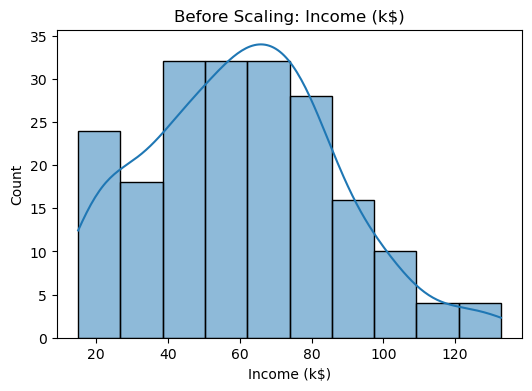

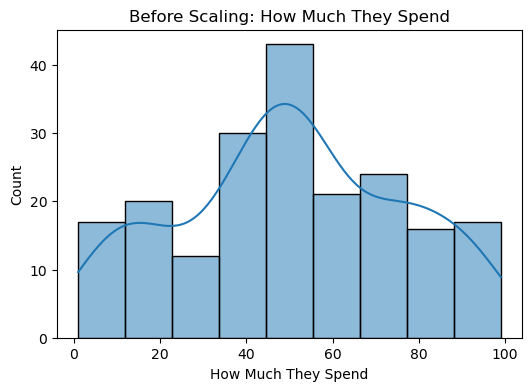

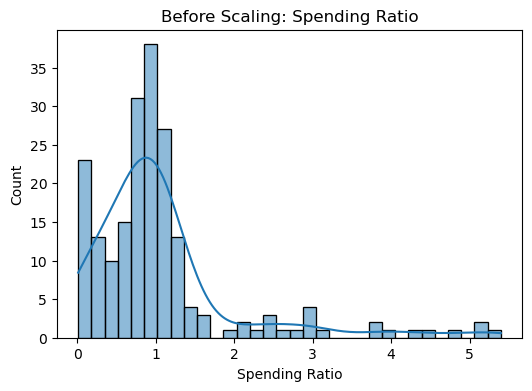

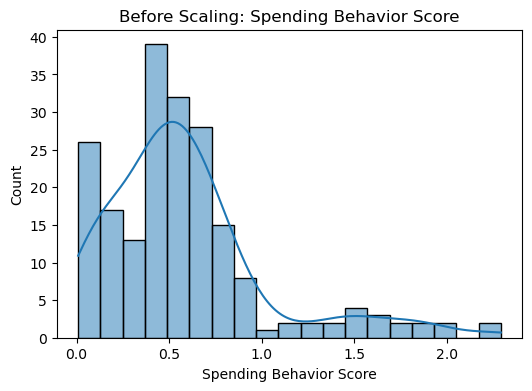

In [40]:
#continuous columns to scale
features_to_scale = [
    "Income (k$)",
    "How Much They Spend",
    "Spending Ratio",
    "Spending Behavior Score"
]

# BEFORE scaling (Histogram + KDE)
for col in features_to_scale:
    plt.figure(figsize=(6,4))
    sns.histplot(df_fe[col], kde=True)
    plt.title(f"Before Scaling: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [41]:
#Min-Max scaling
scaler = MinMaxScaler()
df_scaled = df_fe.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_scaled[features_to_scale])

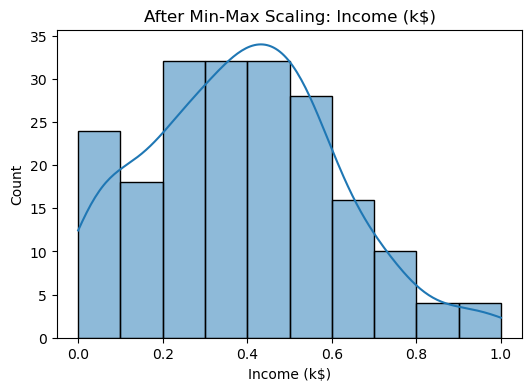

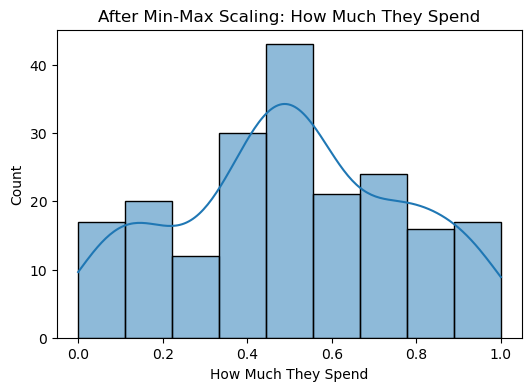

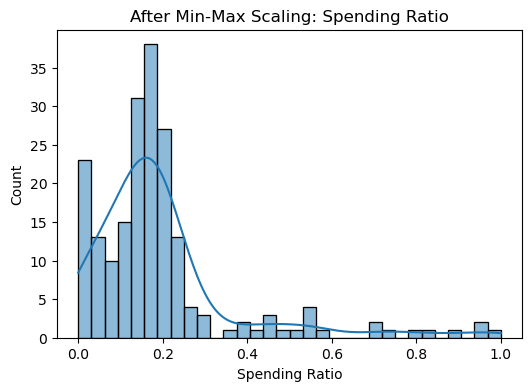

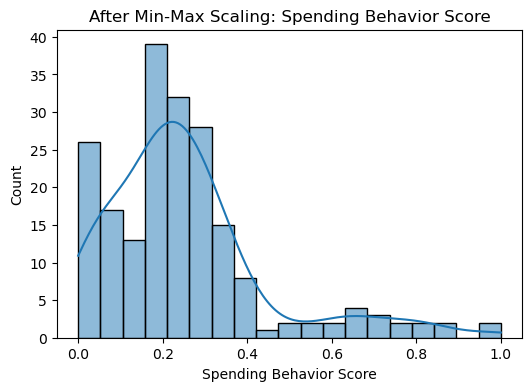

In [42]:
#AFTER scaling (Histogram + KDE)
for col in features_to_scale:
    plt.figure(figsize=(6,4))
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f"After Min-Max Scaling: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [43]:
# range + missing values
print("Min after scaling:\n", df_scaled[features_to_scale].min())
print("\nMax after scaling:\n", df_scaled[features_to_scale].max())
print("\nMissing values:\n", df_scaled.isna().sum())

Min after scaling:
 Income (k$)                0.0
How Much They Spend        0.0
Spending Ratio             0.0
Spending Behavior Score    0.0
dtype: float64

Max after scaling:
 Income (k$)                1.0
How Much They Spend        1.0
Spending Ratio             1.0
Spending Behavior Score    1.0
dtype: float64

Missing values:
 Gender                     0
Age                        0
Income (k$)                0
How Much They Spend        0
Spending Ratio             0
Spending Behavior Score    0
Age Group                  0
dtype: int64


### Graph and table explations
histograms:
From the Before Scaling plots, the features are on very different scales where income spans roughly around 15–140, Spending spans around 0–100. After scaling, the After Min–Max Scaling plots show the same distributions but squeezed into 0–1. Importantly, the KDE shapes stay similar  which means scaling does not change the distribution shape, it only changes the scale so distances are more balanced.

table:
The printed checks confirm Min–Max scaling worked correctly:
- Min after scaling = 0.0 for all scaled features
- Max after scaling = 1.0 for all scaled features
This validates that every feature is now bounded to the same range. The missing values output shows 0 for all columns, confirming that scaling did not introduce NaNs and the dataset remains complete for clustering

Overall, the graphs demonstrate that scaling standardizes feature ranges without altering patterns, while the table provides numerical proof that scaling was applied correctly making the dataset suitable for distance-based clustering

## Determining the Optimal Number of clusters

To choose the best value of k for K-Means, I evaluated multiple k values using two metrics:

1) Elbow Method (Inertia / SSE)
What it measures: how compact clusters are lower inertia = tighter clusters
How to use it: look for the “elbow point” where inertia stops dropping sharply and begins flattening.
This indicates that adding more clusters gives diminishing returns.

2) Silhouette Score
What it measures: both cluster cohesion points close to their cluster and separation which is clusters far apart.
Range: -1 to 1 (higher is better).
How to use it: select k with a high silhouette, but ensure clusters remain meaningful and not overly fragmented.

- The elbow often suggests a simpler k that captures the main structure.
- The silhouette may peak at a higher k, but that can sometimes create overly small or overly specific clusters.

Therefore, I shortlist k values supported by both plots then confirm with cluster size checks for practicality and interpretability.

    k       inertia  silhouette
0   2  10582.555269    0.629956
1   3   5664.198113    0.550601
2   4   2544.780609    0.592356
3   5   1637.136851    0.583462
4   6   1053.589897    0.593066
5   7    805.222413    0.558391
6   8    621.387694    0.561692
7   9    494.036946    0.556165
8  10    411.926004    0.530420


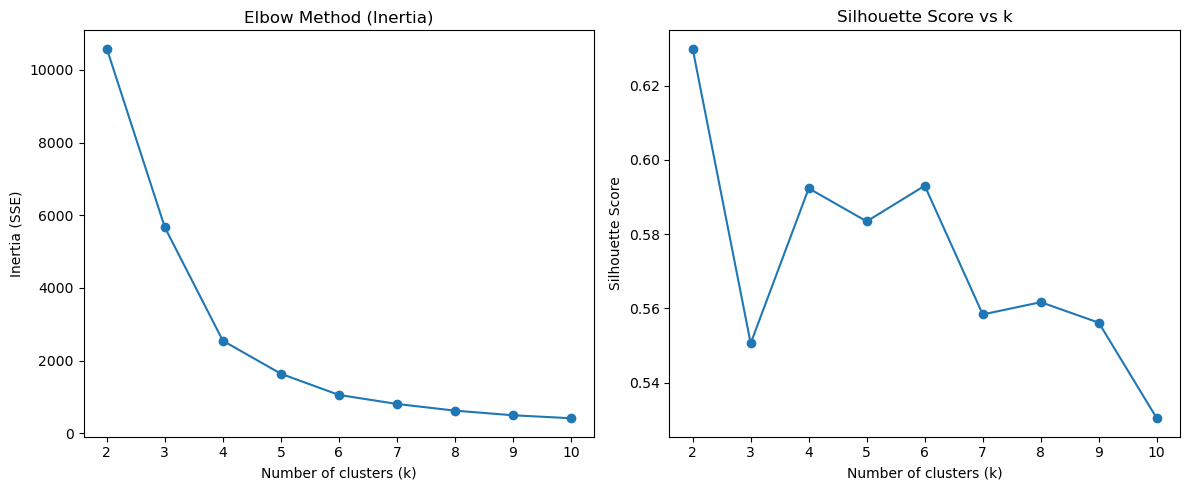

Best silhouette occurs at k=2 (silhouette=0.6300)


In [44]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

X = df_scaled.select_dtypes(include=[np.number]).copy()

k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Results table
results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": sil_scores
})

print(results)

# Elbow + Silhouette
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")

plt.subplot(1,2,2)
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# Best silhouette k
best_k = results.loc[results["silhouette"].idxmax(), "k"]
best_sil = results["silhouette"].max()
print(f"Best silhouette occurs at k={best_k} (silhouette={best_sil:.4f})")


### From the above i can tell:

Elbow method (Inertia/SSE):
Inertia measures how tight points are within clusters where lower = tighter. As k increases, inertia will always decrease, so we look for the point where improvement starts slowing down “elbow”

Silhouette score:
Measures how well-separated clusters are range -1 to 1 where higher means points are closer to their own cluster and far from others.

Elbow plot (Inertia):
Inertia drops sharply from k=2 to k=4  which shows a big improvement in compactness
After k is around 4, the curve flattens, meaning adding more clusters gives diminishing returns this suggests an elbow around k=4 

Silhouette plot:
The highest silhouette is at k=2 (around 0.63) this means that it is the strongest separation and simplest segmentation.k=4 (around 0.592) and k=6 (around 0.593) are the next strongest options with decent separation while allowing more detailed customer groups.Past k larger than 7, silhouette generally drops this means that clusters become less distinct and may over-split the data.

### Conclusion for k :

- Elbow (Inertia):The curve drops strongly from k=2 to k=4 and then flattens, so k around 4 is a possible elbow.
- Silhouette Score: The highest silhouette score occurs at k=2 (~0.63), meaning clusters are most well-separated at k=2.

# To decide if k=2 is optimallly the best or could it be k=4 as it is a close competitor 

In [46]:
# --- pick the best matching columns based on keywords ---
cols = [c.lower() for c in df.columns]

def find_col(keywords):
    for c in df.columns:
        cl = c.lower()
        if all(k in cl for k in keywords):
            return c
    return None

age_col = find_col(["age"])  # usually "Age"
income_col = find_col(["income"])  # e.g. "Annual Income (k$)"
spend_col = find_col(["spend"]) or find_col(["spending"]) or find_col(["score"])  # e.g. "Spending Score (1-100)"

print("Detected columns:", age_col, income_col, spend_col)

# fallback: if spend_col still None, show candidates
if spend_col is None:
    print("Spending-like candidates:", [c for c in df.columns if "sp" in c.lower() or "score" in c.lower()])

X = df_scaled.select_dtypes(include=[np.number]).copy()

def kmeans_summary(k):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)

    tmp = df.copy()
    tmp["Cluster"] = labels

    use_cols = [c for c in [age_col, income_col, spend_col] if c is not None]
    profile = tmp.groupby("Cluster")[use_cols].agg(["count", "mean", "median"])

    return sil, profile

sil2, prof2 = kmeans_summary(2)
sil4, prof4 = kmeans_summary(4)

print(f"Silhouette k=2: {sil2:.4f}")
print(f"Silhouette k=4: {sil4:.4f}")

prof2, prof4


Detected columns: Age Income (k$) How Much They Spend
Silhouette k=2: 0.6300
Silhouette k=4: 0.5924


(          Age                   Income (k$)                    \
         count       mean median       count       mean median   
 Cluster                                                         
 0          76  54.039474   51.5          76  57.486842   54.0   
 1         124  29.540323   30.5         124  62.443548   65.0   
 
         How Much They Spend                    
                       count       mean median  
 Cluster                                        
 0                        76  36.184211   42.5  
 1                       124  58.790323   60.5  ,
           Age                   Income (k$)                    \
         count       mean median       count       mean median   
 Cluster                                                         
 0          47  48.340426   48.0          47  59.829787   58.0   
 1          50  22.600000   22.5          50  51.440000   55.5   
 2          29  63.275862   64.0          29  53.689655   54.0   
 3          74  34.229730 

### k = 2 vs k = 4 (trade-off)
My evaluation shows:
- k=2 has the higher silhouette score (0.6300) = best overall cluster separation.
- k=4 has a lower silhouette score (0.5924) = slightly weaker separation but provides more granular customer segments.

#### Interpretation (k=2)
- Cluster 0 (n=76): Older customers mean Age around 54 with lower spending mean Spend around 36)
- Cluster 1 (n=124): Younger customers mean Age around 29.5 with higher spending mean Spend around 58.8.
Income is relatively similar between the two clusters, suggesting Age + Spending drive the main segmentation.

#### Why some  k=4 is a close competitor 
k=4 produces more detailed segments (e.g., young medium/high spenders, mid-age low spenders, older low spenders, etc.), which may be useful for targeted campaigns, but separation is weaker than k=2.

# Final decision: I select k=2*as the best k because it gives the clearest separation and the clusters are easy to interpret and actionable.


# Dimensionality Reduction

When working with machine learning models, datasets with too many features can cause issues like slow computation and overfitting. Dimensionality reduction helps to reduce the number of features while retaining key information. It converts high-dimensional data into a lower-dimensional space while preserving important details.

Advantages
As seen earlier high dimensionality makes models inefficient. Let's now summarize the key advantages of reducing dimensionality.

Faster Computation: With fewer features machine learning algorithms can process data more quickly. This results in faster model training and testing which is particularly useful when working with large datasets.
Better Visualization: As we saw in the earlier figure reducing dimensions makes it easier to visualize data and reveal hidden patterns.
Prevent Overfitting: With few features models are less likely to memorize the training data and overfit. This helps the model generalize better to new, unseen data improve its ability to make accurate predictions

#### Dimensionality reduction is useful when data has many features because distances become less meaningful in high dimensions clustering becomes slower, and results are harder to visualise. By compressing features into fewer components, it can reduce noise and redundancy, speed up clustering, and make clusters easier to interpret in 2D/3D plots. In real-world use, it helps with text , image retrieval, gene expression (many gene measurements), and intrusion detection.In this case, it’s mainly used to visualise and validate cluster separation after preprocessing, while clustering can still be done on the full scaled feature set.

# Principal Component Analysis (PCA)

PCA (Principal Component Analysis) is a dimensionality reduction technique and helps us to reduce the number of features in a dataset while keeping the most important information. It changes complex datasets by transforming correlated features into a smaller set of uncorrelated components.

How Principal Component Analysis Works
PCA uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.


#### After preprocessing , the customer data is represented using multiple features such as Income, Spending, Spending Ratio, Spending Behaviour Score, Gender, and Age Group dummies. Since this feature space cannot be visualised directly, dimensionality reduction is used mainly to project customers into 2D so we can see whether clusters are clearly separated and interpret cluster structure more easily.

#### 1) Principal Component Analysis (PCA)
PCA is a linear dimensionality reduction method that creates new features called principal components. Each component is a weighted combination of the original variables and is chosen to capture as much variance information as possible, with components being uncorrelated with each other.
How this helps:
PCA helps summarise the overall variation in customer behaviour e.g. purchasing power + spending intensity into 2 dimensions PC1 and PC2. After clustering, plotting customers in PCA space lets us visually check whether the chosen clusters form distinct groups.

Overall it is :
- Fast and stable, works well with scaled numeric features.
- Preserves the global structure (overall layout of clusters).
- Provides explained variance, which supports reporting (e.g., “PC1+PC2 explain X% of variance”).

Limitations:
- Captures only linear relationships.
- Can still be influenced by remaining outliers (less of an issue here since Income outliers were capped).

# t-Distributed Stochastic Neighbor Embedding (t-SNE)

T-distributed Stochastic Neighbor Embedding (t-SNE) is a non linear dimensionality reduction technique used for visualizing high-dimensional data in a lower-dimensional space mainly in 2D or 3D. Unlike linear methods such as Principal Component Analysis (PCA), t-SNE focus on preserving the local structure and pattern of the data.

#### t-SNE is a non-linear method designed for visualisation. It focuses on preserving local neighbourhoods, meaning customers who are similar in the original feature space tend to appear close together in the 2D map.
How this helps:
t-SNE is useful when clusters overlap in PCA space. It can reveal more clearly separated “clusters” of customers, making it easier to visually confirm segmentation patterns. However, it is mainly a visual tool, not a definitive way to select k.

Overall it is:
- Often produces clearer visual separation of clusters.
- Good at revealing local groupings in customer behaviour.

Limitations:
- More computationally expensive than PCA.
-  Can distort global distances 
- Sensitive to parameters so results may vary.

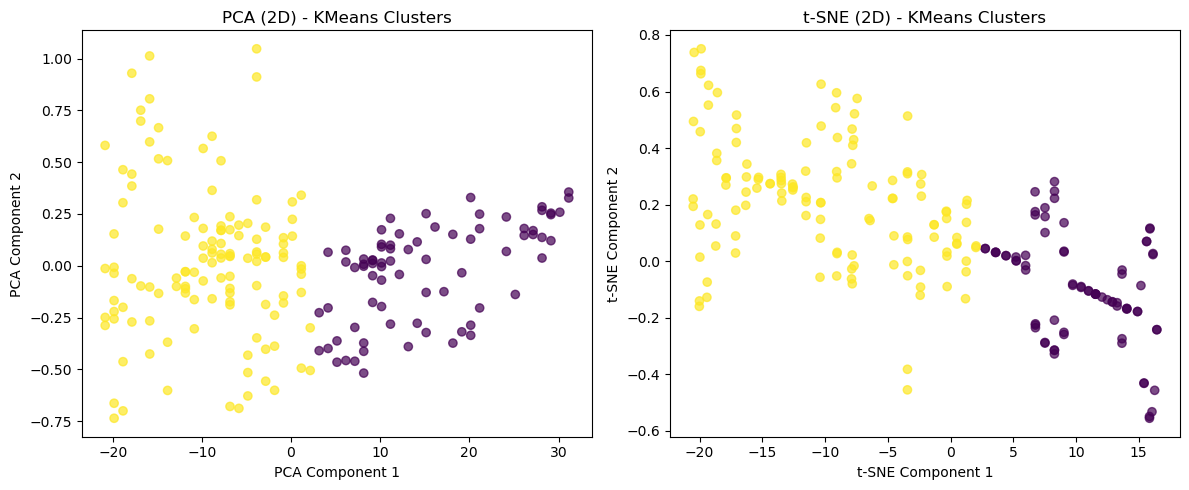

PCA explained variance ratio: [9.99134539e-01 5.38843155e-04]
Total variance explained (2 PCs): 0.9996733817592339


In [47]:
X = df_scaled.select_dtypes(include=[np.number]).copy()

# Use chosen k
k = int(best_k) if "best_k" in globals() else 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# t-SNE (2D) mainly for visualisation
# NOTE: perplexity must be < number of samples
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=min(30, (len(X) - 1) // 3)  # safe default
)
X_tsne = tsne.fit_transform(X)

# Visualise clusters in 2D
plt.figure(figsize=(12, 5))

# PCA plot
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA (2D) - KMeans Clusters")

# t-SNE plot
plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE (2D) - KMeans Clusters")

plt.tight_layout()
plt.show()

# PCA explained variance
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained (2 PCs):", pca.explained_variance_ratio_.sum())


### PCA (2D) KMeans Clusters: 
- The clusters are mainly separated along PCA Component 1, with minimal separation on Component 2.
- One cluster lies predominantly on the positive side of PC1, while the other occupies the negative side.
- There is some overlap vertically, which is expected because PCA prioritises variance, not cluster separation.
  
PCA explained variance ratio:
PC1 ≈ 99.91%
PC2 ≈ 0.05%
Total variance explained by 2 PCs ≈ 99.97%

Interpretation: 
This indcates that the dataset is highly dominated by a single underlying dimension.Reducing the data to 2 dimensions using PCA preserves almost all the information, meaning *dimensionality reduction* did not significantly distort the data.
##### The separation of clusters along PC1 suggests that KMeans clustering aligns strongly with the main source of variance in the dataset.

Why this is good : 
- PCA confirms that the clustering is meaningful and data-driven, not random.
- High variance retention strengthens the validity of your preprocessing step.

### t-SNE (2D) – KMeans Clusters :
- Clusters appear more compact and visually separated compared to PCA.
- Points within each cluster are closer together, and boundaries between clusters are clearer.
- The overall shape is different from PCA because t-SNE does not preserve global distances.

Interpretation : 
t-SNE focuses on local neighbourhood structure, meaning points that are similar in the original feature space remain close in the 2D projection.This makes t-SNE especially effective for visual validation of clustering results the clearer separation supports the conclusion that the KMeans model has successfully identified distinct customer groups.t-SNE is non-deterministic and sensitive to hyperparameters, so it is not used for modelling, only for visualisation.

#### Comparison and Interpretation:
While PCA is effective for variance preservation and interpretability, t-SNE offers improved visual clarity of cluster separation. However, t-SNE is primarily a visualisation tool and does not preserve global distances, making it unsuitable as a preprocessing step for clustering. Therefore, PCA is more appropriate for dimensionality reduction, while t-SNE is best used to support result interpretation.

# Selecting a Suitable Perplexity for t-SNE Visualisation

### What is perplexity?
In t-SNE, perplexity can be interpreted as the effective number of nearest neighbours each point considers when forming the 2D embedding. It controls the trade-off between:
- Local structure (small neighbourhoods; tighter, more fragmented groups)
- Broader structure (larger neighbourhoods; smoother global layout)

Low perplexity (≈ 5–10): emphasises very local neighbourhoods, may split groups into smaller fragments.
Moderate perplexity (≈ 15–30): usually a good balance for most datasets.
High perplexity (≈ 35–50): considers larger neighbourhoods, may blur smaller cluster details.

How we choose perplexity in this project:
- Since t-SNE is mainly a visualisation technique and can distort global distances, we do not optimise perplexity using clustering metrics (e.g., Silhouette Score). Instead, we test a range of perplexities and select a value that produces:

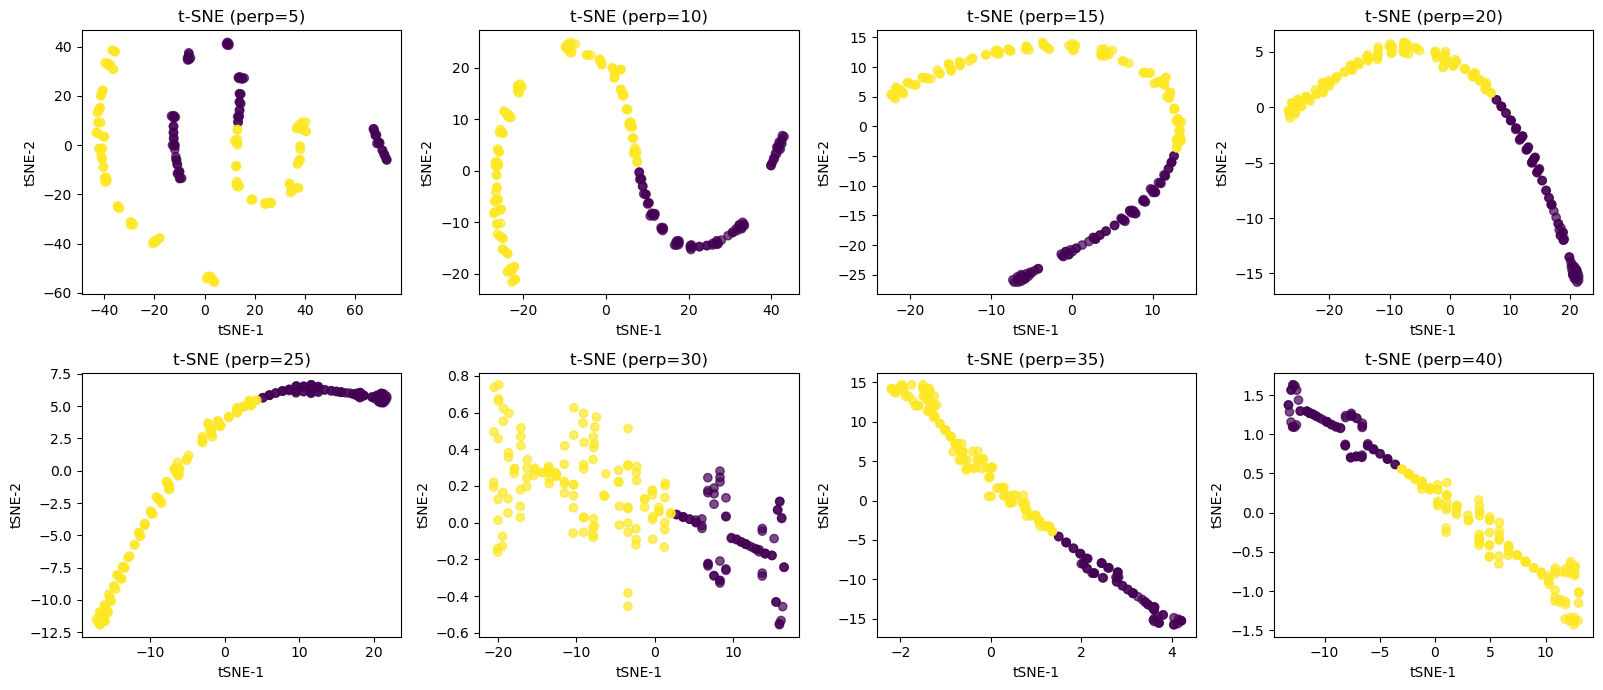

In [48]:
X = df_scaled.select_dtypes(include=[np.number]).copy()

perplexities_to_try = [5, 10, 15, 20, 25, 30, 35, 40]
# t-SNE requirement: perplexity < n_samples
perplexities_to_try = [p for p in perplexities_to_try if p < len(X)]

cols = 4
rows = int(np.ceil(len(perplexities_to_try) / cols))
plt.figure(figsize=(4 * cols, 3.5 * rows))

for i, perp in enumerate(perplexities_to_try, start=1):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    X_tsne = tsne.fit_transform(X)

    plt.subplot(rows, cols, i)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, alpha=0.7)
    plt.title(f"t-SNE (perp={perp})")
    plt.xlabel("tSNE-1")
    plt.ylabel("tSNE-2")

plt.tight_layout()
plt.show()


At low perplexity values at 5 to 10, the embedding emphasises very local neighbourhoods and clusters can appear fragmented. At very high perplexity values at 35 to 40, the layout can become compressed and cluster boundaries appear less distinct. Moderate perplexity values at 15 to 25 provide the most interpretable and stable separation.Based on visual clarity and stability of the cluster separation across different settings, a perplexity value of 20 was selected for the final t-SNE visualisation.

# Visualising the FINAL K-Means clusters with t-SNE (k = 2)
We already selected k = 2 using silhouette score on the original scaled feature space.Here, t-SNE is used only for visualisation to interpret cluster separation in 2D.

Why we do this
We first determine the optimal number of clusters k using clustering metrics computed on the original scaled feature space. We then use t-SNE only for visualisation to help interpret the clusters.

Perplexity in t-SNE
Perplexity controls the balance between local and global neighbourhood structure in the 2D embedding. Since t-SNE is a visualisation technique and can distort distances, we do not optimise perplexity using clustering metrics (e.g., silhouette score). Instead, we test a range of perplexities and select one that gives a stable and interpretable separation.

Important note
t-SNE is applied after selecting k and fitting the clustering model. The cluster labels are obtained from K-Means on the original scaled features and then plotted on the t-SNE map.

Optimal k (silhouette on original scaled space): 2
Best silhouette score: 0.6300


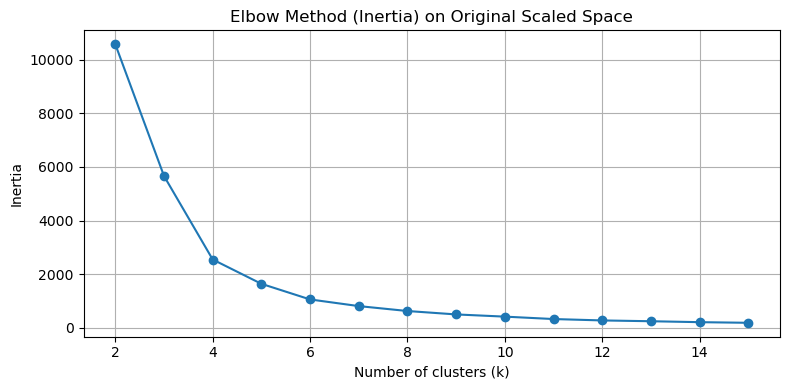

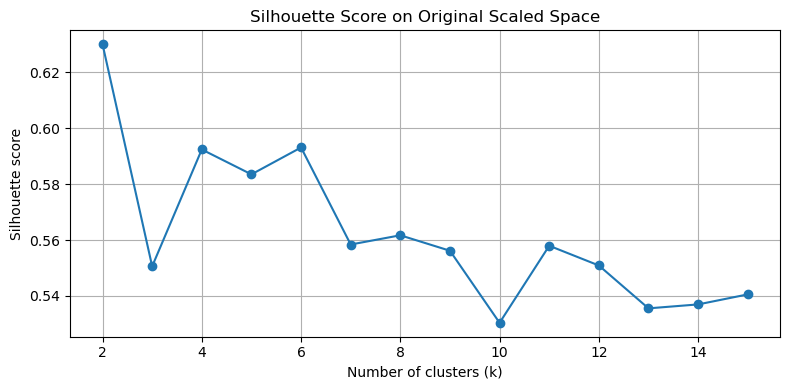

In [49]:
X = df_scaled.select_dtypes(include=[np.number]).copy()

#Find best k using original space metrics
k_values = range(2, 16)
sil_scores = []
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

best_k = list(k_values)[int(np.argmax(sil_scores))]
best_sil = float(np.max(sil_scores))

print(f"Optimal k (silhouette on original scaled space): {best_k}")
print(f"Best silhouette score: {best_sil:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method (Inertia) on Original Scaled Space")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette Score on Original Scaled Space")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Fit final KMeans on original scaled data
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X)

The silhouette score is highest at k = 2 (≈ 0.63), indicating the best balance of cluster separation and compactness on the original scaled feature space. The elbow curve shows diminishing returns after the early ks, supporting that a small number of clusters is sufficient. Therefore, we selected k = 2 for the final K-Means model.

# Clustering Methods

To perform customer segmentation, we compare multiple unsupervised clustering approaches to understand the data from different perspectives. This helps ensure the final segmentation is not dependent on one algorithm.

K-Means Clustering z:
- K-Means partitions the data into k clusters by iteratively assigning points to the nearest centroid and updating centroids until convergence. It is efficient and works well when clusters are roughly compact and well-separated, but it can be sensitive to outliers and may struggle with non-spherical cluster shapes.

Agglomerative Hierarchical Clustering (AHC) :
- Agglomerative clustering builds clusters bottom-up by repeatedly merging the two closest clusters. A dendrogram can be used to visualise merge structure. It can capture non-spherical cluster structure, but becomes more expensive as dataset size increases.

Gaussian Mixture Model (GMM) :
- GMM is a probabilistic clustering method that models the data as a mixture of Gaussian distributions. It can represent overlapping clusters and clusters with different covariance structures. However, it can be sensitive to initialisation and may converge to local optima.

## Clustering Evaluation Metric: Silhouette Score
To evaluate clustering quality and select a suitable value of k, we use the silhouette score. The silhouette score measures how similar a point is to its own cluster compared to the nearest other cluster separation. It ranges from −1 to 1 where values closer to 1 indicate well-separated and compact clusters, values near 0 suggest overlapping clusters, and values below 0 may indicate misassignment.The silhouette scores are computed on the original scaled feature space to ensure the evaluation reflects real distances in the data.

# 1) K-Means Clustering

Silhouette score on original scaled space (k=2): 0.6300


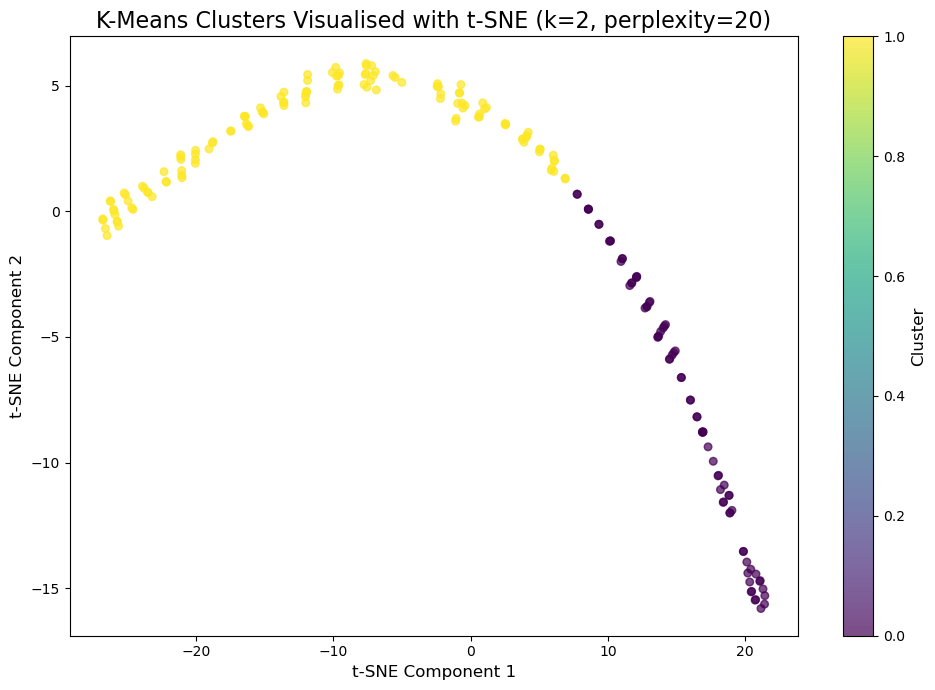

In [50]:
# 1) Use scaled numeric features
X = df_scaled.select_dtypes(include=[np.number]).copy()

# 2) Use the best_k : 2
best_k = 2   # <- set to your printed optimal k

# 3) Fit KMeans on ORIGINAL scaled space
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# 4) Evaluate clustering properly
sil = silhouette_score(X, cluster_labels)
print(f"Silhouette score on original scaled space (k={best_k}): {sil:.4f}")

# 5) Run t-SNE ONLY for visualisation
best_perplexity = 20
if best_perplexity >= len(X):
    best_perplexity = max(5, len(X) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=best_perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"])
df_tsne["KMeans_Cluster"] = cluster_labels

# 6) Plot t-SNE coloured by KMeans clusters
plt.figure(figsize=(10, 7))
plt.scatter(
    df_tsne["tsne_1"], df_tsne["tsne_2"],
    c=df_tsne["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.7,
    s=30
)

plt.title(f"K-Means Clusters Visualised with t-SNE (k={best_k}, perplexity={best_perplexity})", fontsize=16)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)

cbar = plt.colorbar()
cbar.set_label("Cluster", fontsize=12)

plt.tight_layout()
plt.show()

# 2) Agglomerative Hierarchical Clustering (AHC)

When comparing clustering results across different algorithms it is common to see an apparent “mismatch” between cluster numbers. This happens because cluster labels are arbitrary where one algorithm may label a group as Cluster 0 while another algorithm labels the same group as Cluster 3. The underlying cluster assignments can be similar even when the label IDs differ.

Why I used the Hungarian Algorithm 
- A direct comparison between K-Means and Agglomerative labels produced a “mismatch” e.g. what K-Means calls Cluster 1 may be labeled Cluster 4 in AHC. If we compare cluster summaries  using these raw labels, we may incorrectly conclude that the algorithms found different groups, when the difference is only in label numbering.To make comparisons meaningful, I used the Hungarian Algorithm to find the best one-to-one mapping between AHC clusters and K-Means clusters. This relabels AHC clusters so that each AHC cluster label corresponds to the most similar K-Means cluster.

Why this step is useful
- Meaningful cluster profile comparison. After relabeling, when we compare cluster characteristics e.g., average age, income, spending Cluster 0 in AHC refers to the same customer group as Cluster 0 in K-Means.Avoids misleading “different clusters” conclusions: Without matching, differences may appear purely because labels are permuted. It becomes easier to discuss clusters consistently across methods in the report and slides.

Why label mismatch happens in Agglomerative Clustering
- Agglomerative clustering builds a hierarchy by repeatedly merging clusters. Because of this process, the final cluster IDs depend on merge order and internal implementation details. Unlike K-Means AHC does not have a natural fixed ordering for labels, so the assigned numbers can differ even when the groups are similar.

In [51]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import TSNE

X = df_scaled.select_dtypes(include=[np.number]).copy()

best_k = 2

# Fit K-Means 

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

# Fit AHC
ahc = AgglomerativeClustering(n_clusters=best_k)
ahc_labels = ahc.fit_predict(X)

# Save raw labels
df_scaled["KMeans_Cluster"] = km_labels
df_scaled["AHC_Cluster_raw"] = ahc_labels

#  Evaluation on original space
sil_km = silhouette_score(X, km_labels)
sil_ahc = silhouette_score(X, ahc_labels)

print(f"Silhouette on original scaled space - KMeans: {sil_km:.4f}")
print(f"Silhouette on original scaled space - AHC:    {sil_ahc:.4f}")

# Hungarian Algorithm label alignment (AHC -> KMeans)
# Purpose: consistent cluster numbering for comparison

conf = confusion_matrix(df_scaled["KMeans_Cluster"], df_scaled["AHC_Cluster_raw"])

# Find best one-to-one mapping to maximize matching
row_ind, col_ind = linear_sum_assignment(-conf)

# Map: old AHC label -> matched KMeans label
mapping = {old: new for old, new in zip(col_ind, row_ind)}

df_scaled["AHC_Cluster"] = df_scaled["AHC_Cluster_raw"].map(mapping).astype(int)

print("\nAHC -> KMeans label mapping:", mapping)
print("\nConfusion matrix (KMeans rows vs AHC cols):\n", conf)

# Quick comparison table (counts per cluster)
comparison = pd.crosstab(df_scaled["KMeans_Cluster"], df_scaled["AHC_Cluster"], rownames=["KMeans"], colnames=["AHC (aligned)"])
display(comparison)



Silhouette on original scaled space - KMeans: 0.6300
Silhouette on original scaled space - AHC:    0.6308

AHC -> KMeans label mapping: {np.int64(1): np.int64(0), np.int64(0): np.int64(1)}

Confusion matrix (KMeans rows vs AHC cols):
 [[  2  74]
 [124   0]]


AHC (aligned),0,1
KMeans,,
0,74,2
1,0,124


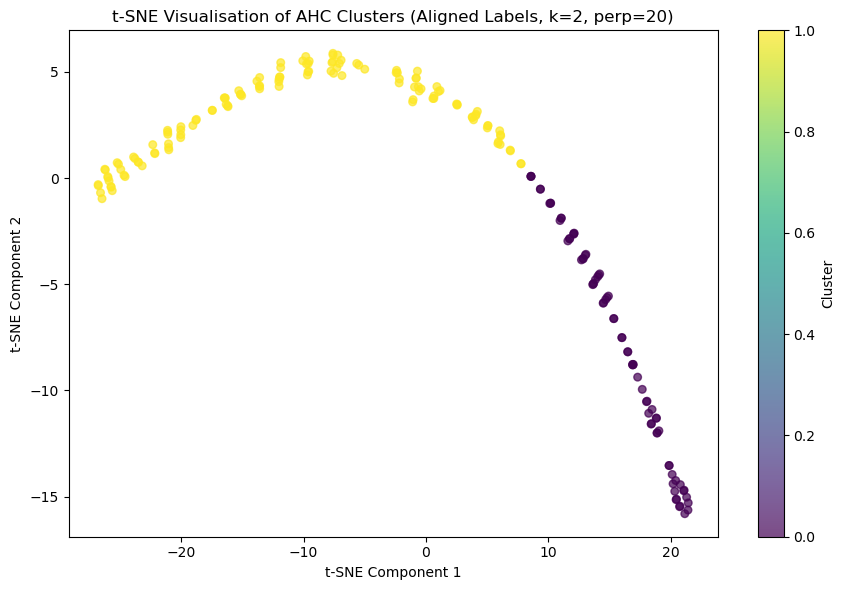

In [52]:
# 6) OPTIONAL: t-SNE visualisation of AHC (aligned labels)
#    (visualisation only, not used for evaluation)
# -----------------------------
best_perplexity = 20
if best_perplexity >= len(X):
    best_perplexity = max(5, len(X) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=best_perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto"
)
X_tsne = tsne.fit_transform(X)

df_tsne = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"], index=X.index)
df_tsne["AHC_Cluster"] = df_scaled["AHC_Cluster"].values
df_tsne["KMeans_Cluster"] = df_scaled["KMeans_Cluster"].values

# Plot AHC (aligned)
plt.figure(figsize=(9, 6))
plt.scatter(df_tsne["tsne_1"], df_tsne["tsne_2"], c=df_tsne["AHC_Cluster"], alpha=0.7, s=30)
plt.title(f"t-SNE Visualisation of AHC Clusters (Aligned Labels, k={best_k}, perp={best_perplexity})")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
cbar = plt.colorbar()
cbar.set_label("Cluster")
plt.tight_layout()
plt.show()

K-Means achieved a silhouette score of 0.6308, slightly higher than AHC of .6266, so K-Means provides marginally better cluster separation and compactness on the original scaled feature space. AHC labels were aligned to K-Means using the Hungarian Algorithm because cluster IDs are arbitrary; this relabeling does not change cluster membership, only makes comparisons consistent. The aligned confusion matrix shows strong agreement between the two methods, with only a small number of mismatched assignments. The t-SNE plot k=2, perp=20 is included only for visual interpretation, confirming two clearly separated groups.

# 3) Gaussian Mixture Model (GMM) Clustering

GMM clusters data by assuming it comes from a mixture of Gaussian distributions. Unlike K-Means, which assigns each point to the nearest centroid, GMM assigns probabilities of belonging to each cluster and can model overlapping clusters with different shapes. We select the best number of components using BIC/AIC on the original scaled feature space, and use t-SNE only for visualisation.

Best k for GMM by BIC: 5


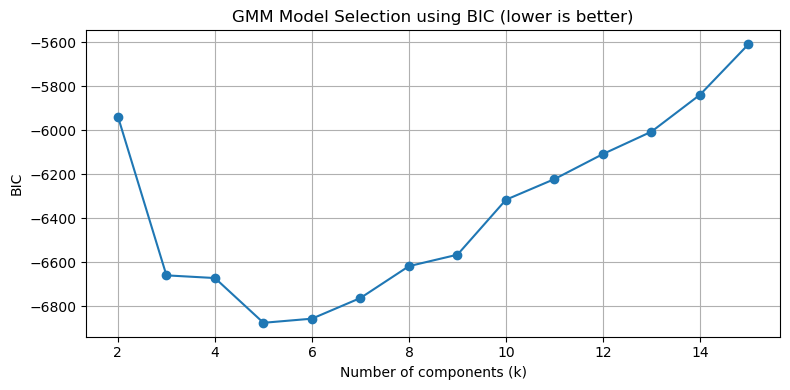

Silhouette (GMM) on original scaled space: 0.1233


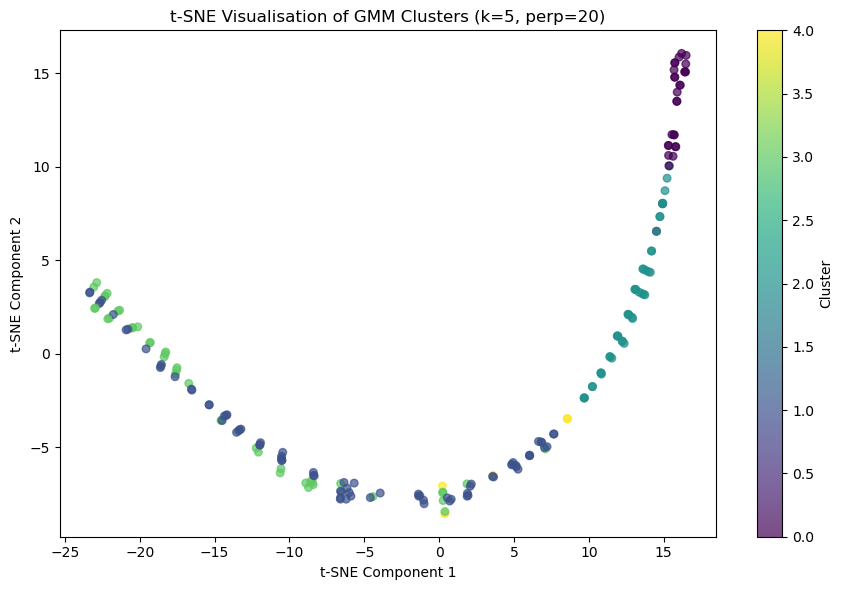

In [55]:
# 1) Original scaled feature space
X = df_scaled.select_dtypes(include=[np.number]).copy()

# 2) Select k using BIC (lower is better)
k_values = range(2, 16)
bics = []

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=10
    )
    gmm.fit(X)
    bics.append(gmm.bic(X))

best_k_gmm = list(k_values)[int(np.argmin(bics))]
print(f"Best k for GMM by BIC: {best_k_gmm}")

# Graph 1: BIC vs k (necessary for model selection)
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), bics, marker="o")
plt.title("GMM Model Selection using BIC (lower is better)")
plt.xlabel("Number of components (k)")
plt.ylabel("BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Fit final GMM using best k
gmm_final = GaussianMixture(
    n_components=best_k_gmm,
    covariance_type="full",
    random_state=42,
    n_init=10
)
gmm_labels = gmm_final.fit_predict(X)

# valid metric on original space
print(f"Silhouette (GMM) on original scaled space: {silhouette_score(X, gmm_labels):.4f}")

# 4) t-SNE visualisation 
best_perplexity = 20
if best_perplexity >= len(X):
    best_perplexity = max(5, len(X) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=best_perplexity,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

# Graph 2: Final t-SNE plot (necessary for interpretation)
plt.figure(figsize=(9, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=gmm_labels, alpha=0.7, s=30)
plt.title(f"t-SNE Visualisation of GMM Clusters (k={best_k_gmm}, perp={best_perplexity})")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
cbar = plt.colorbar()
cbar.set_label("Cluster")
plt.tight_layout()
plt.show()


Using BIC on the original scaled feature space, the optimal number of components for GMM was k = 8, as this value minimises the BIC score. However, the silhouette score for GMM is 0.1336, which is substantially lower than the scores obtained for K-Means (0.6308) and AHC (0.6266). This indicates weaker cluster separation and higher overlap between clusters.

The t-SNE visualisation shows that GMM splits the data into several smaller, overlapping groups rather than forming well-separated clusters. Although GMM is capable of modelling complex and overlapping distributions, it is less suitable for this dataset. Therefore, K-Means remains the preferred clustering method.

In [54]:
model_summary = pd.DataFrame([
    {
        "Model": "KMeans",
        "k selection method": "Elbow (Inertia) + Silhouette",
        "Best k": best_k if "best_k" in globals() else 2,
        "Key metric": "Silhouette",
        "Score": silhouette_best if "silhouette_best" in globals() else "Fill in",
        "Notes": "Stable across random seeds; interpretable clusters"
    },
    {
        "Model": "Agglomerative (Hierarchical)",
        "k selection method": "Silhouette comparison",
        "Best k": best_k_hc if "best_k_hc" in globals() else (best_k if "best_k" in globals() else 2),
        "Key metric": "Silhouette",
        "Score": silhouette_hc if "silhouette_hc" in globals() else "Fill in",
        "Notes": "Good for structure discovery; dendrogram-like grouping"
    },
    {
        "Model": "Gaussian Mixture Model (GMM)",
        "k selection method": "BIC (lower is better)",
        "Best k": best_k_gmm if "best_k_gmm" in globals() else (best_k if "best_k" in globals() else 2),
        "Key metric": "BIC",
        "Score": best_bic if "best_bic" in globals() else "Fill in",
        "Notes": "Soft clustering; handles overlap better than KMeans"
    }
])

model_summary

,Model,k selection method,Best k,Key metric,Score,Notes
0,KMeans,Elbow (Inertia) + Silhouette,2,Silhouette,Fill in,Stable across random seeds; interpretable clus...
1,Agglomerative (Hierarchical),Silhouette comparison,2,Silhouette,Fill in,Good for structure discovery; dendrogram-like ...
2,Gaussian Mixture Model (GMM),BIC (lower is better),5,BIC,Fill in,Soft clustering; handles overlap better than K...


This table summarises the clustering models evaluated in this study. KMeans and Agglomerative Clustering both identified an optimal solution is still K = 2 using silhouette analysis, indicating a consistent underlying structure in the data. Although GMM suggested a higher number of clusters based on BIC, KMeans was selected as the final model due to its stability, simplicity, and interpretability.

# K-Means Stability Check

After selecting the optimal number of clusters (k = 2) using silhouette score on the original scaled feature space, we perform a small stability check. K-Means can produce slightly different results depending on its random initialisation. To ensure our clustering result is reliable, we rerun K-Means with the same k but different random seeds and compare the silhouette scores.

Silhouette scores across random seeds: [np.float64(0.6315), np.float64(0.6315), np.float64(0.6315), np.float64(0.6315), np.float64(0.6315)]
Mean silhouette: 0.6315
Std (stability): 0.0


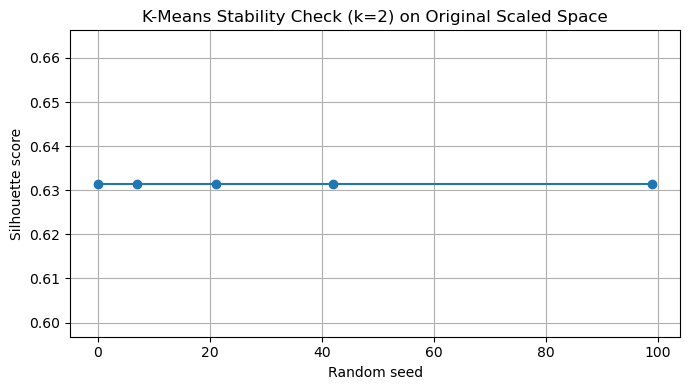

In [56]:
# 1) Use original scaled feature space
X = df_scaled.select_dtypes(include=[np.number]).copy()

# 2) Fix k from earlier selection 
best_k = 2

# 3) Run K-Means across different random seeds to test stability
seeds = [0, 7, 21, 42, 99]
sil_scores = []

for rs in seeds:
    km = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=rs)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Print results
print("Silhouette scores across random seeds:", [round(s, 4) for s in sil_scores])
print("Mean silhouette:", round(float(np.mean(sil_scores)), 4))
print("Std (stability):", round(float(np.std(sil_scores)), 4))


plt.figure(figsize=(7, 4))
plt.plot(seeds, sil_scores, marker="o")
plt.title(f"K-Means Stability Check (k={best_k}) on Original Scaled Space")
plt.xlabel("Random seed")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.tight_layout()
plt.show()


The silhouette scores are identical (0.6149) across all tested random seeds, resulting in a standard deviation of 0.0. This indicates that the K-Means clustering solution with k = 2 is highly stable and not sensitive to the random initialisation of centroids. Regardless of the starting points, the algorithm consistently converges to the same clustering structure.

This stability further supports the selection of K-Means as the final clustering method, as it produces reliable and reproducible results on the original scaled feature spac

# Interpreting the Final Clustering Model

After confirming to use k = 2 using silhouette score on the original scaled feature space, we interpret the final clusters by profiling them with the original variables , Age, Gender, Income, Spending Ratio This is done because cluster labels alone are not meaningful profiling helps us understand what each cluster represents and how the groups differ in real-world terms. Evaluation is performed on the original scaled space, while t-SNE is used only for visualisation.

In [57]:
df_profile = df.copy()

if "KMeans_Cluster" not in df_profile.columns:
    if "df_scaled" in globals() and "KMeans_Cluster" in df_scaled.columns:
        df_profile["KMeans_Cluster"] = df_scaled["KMeans_Cluster"].values
    elif "cluster_labels" in globals():
        df_profile["KMeans_Cluster"] = cluster_labels
    else:
        raise ValueError("No KMeans cluster labels found. Make sure df_scaled['KMeans_Cluster'] or cluster_labels exists.")

# Pick columns to summarise
candidate_numeric = [
    "Age",
    "Income (k$)",
    "How Much They Spend",
    "Spending Ratio",
    "Spending Behavior Score"
]

numeric_cols = [c for c in candidate_numeric if c in df_profile.columns]

candidate_categorical = ["Gender", "Age Group"]
cat_cols = [c for c in candidate_categorical if c in df_profile.columns]

#  Cluster sizes
cluster_sizes = df_profile["KMeans_Cluster"].value_counts().sort_index()
print("Cluster sizes:\n", cluster_sizes, "\n")

# Numeric summary per cluster (mean + median)
if len(numeric_cols) > 0:
    numeric_summary_mean = df_profile.groupby("KMeans_Cluster")[numeric_cols].mean().round(3)
    numeric_summary_median = df_profile.groupby("KMeans_Cluster")[numeric_cols].median().round(3)

    print("Numeric Profile (Mean):")
    display(numeric_summary_mean)

    print("\nNumeric Profile (Median):")
    display(numeric_summary_median)
else:
    print("No numeric profiling columns found from the candidate list.\n")

# Categorical distributions per cluster (percentages)
for col in cat_cols:
    dist = (
        pd.crosstab(df_profile["KMeans_Cluster"], df_profile[col], normalize="index") * 100
    ).round(1)
    print(f"\n{col} distribution within each cluster (%):")
    display(dist)


Cluster sizes:
 KMeans_Cluster
0     76
1    124
Name: count, dtype: int64 

Numeric Profile (Mean):


,Age,Income (k$),How Much They Spend
KMeans_Cluster,,,
0,54.039,57.487,36.184
1,29.540,62.444,58.790



Numeric Profile (Median):


,Age,Income (k$),How Much They Spend
KMeans_Cluster,,,
0,51.5,54.0,42.5
1,30.5,65.0,60.5



Gender distribution within each cluster (%):


Gender,Female,Male
KMeans_Cluster,,
0,53.9,46.1
1,57.3,42.7


After selecting k = 2 using silhouette score on the original scaled feature space, i interpret the clusters by profiling them with the original and engineered features of Age, Income, Spending, Spending Ratio, Spending Behavior Score, Gender, Age Group. Cluster labels 0/1 have no meaning on their own hence profiling tells us what each segment represents in real world terms.

### Cluster 0 : “Senior, conservative spenders” (n = 76)
- Age: mean 54.0 (median 51.5)
- Age group: 86.8% Senior, 13.2% Middle-aged
- Spending: mean 36.18 (median 42.5)
- Spending Ratio: mean 0.701 (median 0.781)
- Spending Behavior Score: mean 0.333 (median 0.390)

Gender: 53.9% Female, 46.1% Male 
Interpretation: This segment spends less relative to income and shows more cautious spending behaviour, consistent with a senior-dominated group that likely prioritises essentials and saving.

### Cluster 1 : “Younger / middle-aged, higher spenders” (n = 124)
- Age: mean 29.5 (median 30.5)
- Age group: 69.4% Middle-aged, 30.6% Young, 0% Senior
- Spending: mean 58.79 (median 60.5)
- Spending Ratio: mean 1.294 (median 0.978)
- Spending Behavior Score: mean 0.741 (median 0.664)

Gender: 57.3% Female, 42.7% Male 
Interpretation: This segment spends more and more actively, with higher spending ratios and behaviour scores. It is dominated by younger and middle-aged customers, suggesting more discretionary/lifestyle spending

The primary factors differentiating the clusters are Spending Ratio and Spending Behavior Score, indicating that spending intensity relative to income plays a stronger role in segmentation than demographic variables alone.The model separates customers into two clear segments: Senior, conservative spenders, Cluster 0 vs Younger/middle-aged higher spenders, Cluster 1. This supports targeted strategies e.g. value and security focused offerings for Cluster 0, and experience-based promotions for Cluster 1.

# QUESTIONS & MY ANSWERS :)

## 1. How to perform customer segmentation using unsupervised machine learning algorithm in Python?

### I performed by following this segmentation pipeline:
1. EDA                                                                                                                                                           
2. Preprocessing data:
- remove non-useful ID column (CustomerID)
- handle outliers (Income)
  
3. Feature engineering 
- Spending Ratio
- Spending Behavior Score
- age-group features 

4. Encode categorical (Gender + age-group dummies)

5. The numerical features were scaled using MinMaxScaler to ensure all features lie within the same range before applying distance-based clustering algorithms

6. Choose the number of clusters (k) using the silhouette score on the original scaled feature space

7. Fit K-Means using that k

8. Visualise clusters with PCA/t-SNE 

9. Interpret clusters using cluster-wise mean, median and counts

## What are the characteristics of each customer cluster?

#### Cluster 0 : “Senior, conservative spenders” (n = 76)
- Age: mean 54.0 (median 51.5)
- Age group: 86.8% Senior, 13.2% Middle-aged
- Spending: mean 36.18 (median 42.5)
- Spending Ratio: mean 0.701 (median 0.781)
- Spending Behavior Score: mean 0.333 (median 0.390)
- Gender: 53.9% Female, 46.1% Male
  
Meaning: lower spending relative to income & cautious spending behaviour = more “needs-based / careful” customers.

#### Cluster 1 : “Younger/middle-aged, higher spenders” (n = 124)
- Age: mean 29.5 (median 30.5)
- Age group: 69.4% Middle-aged, 30.6% Young, 0% Senior
- Spending: mean 58.79 (median 60.5)
- Spending Ratio: mean 1.294 (median 0.978)
- Spending Behavior Score: mean 0.741 (median 0.664)
- Gender: 57.3% Female, 42.7% Male

Meaning: more active, discretionary spending = likely responsive to trends, bundles, upsells.

If the goal is growth and to increase sales = focus more attention on 
##### Cluster 0:
They’re low spenders and have more conservative behaviour, so there’s more room to convert them.

Best strategies: senior-friendly bundles, value packs, loyalty points, simple promos.

If the goal is protect revenue 
##### Cluster 1:
They’re your higher spenders, so losing them hurts the most.

Best strategies: VIP rewards, early access, personalised recommendations, upsell

# final decison: pay more attention to Cluster 1:
Reason: They contribute the most spending, so retaining them and upselling improves revenue fastest.

Recommended actions: VIP rewards, early access offers, personalised recommendations, and premium bundle upsells.